# Лабораторная работа №3
## Классификация временных рядов и прогнозирование метеоданных шести городов России

## 0. Импорты

In [ ]:
import subprocess, sys
import pandas as pd
for pkg in ['tsfresh', 'aeon', 'fastparquet', 'shap', 'numpy', 'pandas', 'matplotlib', 'lightgbm', 'statsmodels', 'scikit-learn']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=True)
print('Зависимости установлены')

Зависимости установлены


In [ ]:
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeClassifierCV
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score, classification_report)

from aeon.classification.feature_based import TSFreshClassifier
try:
    from aeon.classification.feature_based import FreshPRINCEClassifier
    HAS_FRESHPRINCE = True
except ImportError:
    HAS_FRESHPRINCE = False
    print('FreshPRINCEClassifier недоступен в данной версии aeon')

from tsfresh import extract_features, select_features
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import EfficientFCParameters

import lightgbm as lgb
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.stats.diagnostic import acorr_ljungbox
import statsmodels.api as sm

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Все зависимости импортированы успешно')

Все зависимости импортированы успешно


## 1. Загрузка данных

In [ ]:
DATA_DIR = Path('DATA')

CITIES = [
    'Москва', 'Санкт-Петербург', 'Сочи',
    'Геленджик', 'Благовещенск', 'Находка',
]

VARIABLES = [
    'temperature_2m', 'relative_humidity_2m', 'precipitation',
    'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure'
]

def load_city(city: str) -> pd.DataFrame:
    files = sorted(DATA_DIR.glob(f'{city}_*.parquet'))
    if not files:
        raise FileNotFoundError(f"'{city}' не найден {DATA_DIR.resolve()}")
    dfs = []
    for f in files:
        try:
            df = pd.read_parquet(f, engine='fastparquet')
        except Exception:
            df = pd.read_parquet(f, engine='pyarrow')
        time_col = next((c for c in df.columns if c in ('time', 'date')), None)
        if time_col:
            df[time_col] = pd.to_datetime(df[time_col])
            df = df.set_index(time_col)
        elif not isinstance(df.index, pd.DatetimeIndex):
            df.index = pd.to_datetime(df.index)
        cols = [c for c in VARIABLES if c in df.columns]
        dfs.append(df[cols])
    return pd.concat(dfs).sort_index()

raw = {}
for city in CITIES:
    try:
        raw[city] = load_city(city)
        freq = pd.infer_freq(raw[city].index[:100])
        print(f'  {city}: {len(raw[city]):,} записей, частота ≈ {freq}, '
              f'период {raw[city].index[0].date()} — {raw[city].index[-1].date()}')
    except FileNotFoundError as e:
        print(f'  [ОШИБКА] {e}')

  Москва: 61,368 записей, частота ≈ h, период 2019-01-01 — 2025-12-31
  Санкт-Петербург: 61,368 записей, частота ≈ h, период 2019-01-01 — 2025-12-31
  Сочи: 61,368 записей, частота ≈ h, период 2019-01-01 — 2025-12-31
  Геленджик: 61,368 записей, частота ≈ h, период 2019-01-01 — 2025-12-31
  Благовещенск: 61,368 записей, частота ≈ h, период 2019-01-01 — 2025-12-31
  Находка: 61,368 записей, частота ≈ h, период 2019-01-01 — 2025-12-31


In [ ]:
def resample_daily(df):
    agg = {
        'temperature_2m': 'mean',
        'relative_humidity_2m': 'mean',
        'precipitation': 'sum',
        'rain': 'sum',
        'snowfall': 'sum',
        'weathercode': lambda x: x.mode()[0] if len(x) > 0 else np.nan,
        'wind_speed_10m': 'mean',
        'surface_pressure': 'mean',
    }
    freq = pd.infer_freq(df.index[:200])
    if freq and freq.startswith('D'):
        return df[[c for c in agg if c in df.columns]]
    agg_valid = {k: v for k, v in agg.items() if k in df.columns}
    return df.resample('D').agg(agg_valid)

daily = {city: resample_daily(df) for city, df in raw.items()}
print('Размеры суточных датасетов:')
for city, df in daily.items():
    print(f'  {city}: {df.shape}, пропуски: {df.isnull().sum().sum()}')

Размеры суточных датасетов:
  Москва: (2557, 8), пропуски: 0
  Санкт-Петербург: (2557, 8), пропуски: 0
  Сочи: (2557, 8), пропуски: 0
  Геленджик: (2557, 8), пропуски: 0
  Благовещенск: (2557, 8), пропуски: 0
  Находка: (2557, 8), пропуски: 0


## 2.1 Разведочный анализ данных (EDA)
### 2.1.1 Визуальный анализ временных рядов температуры

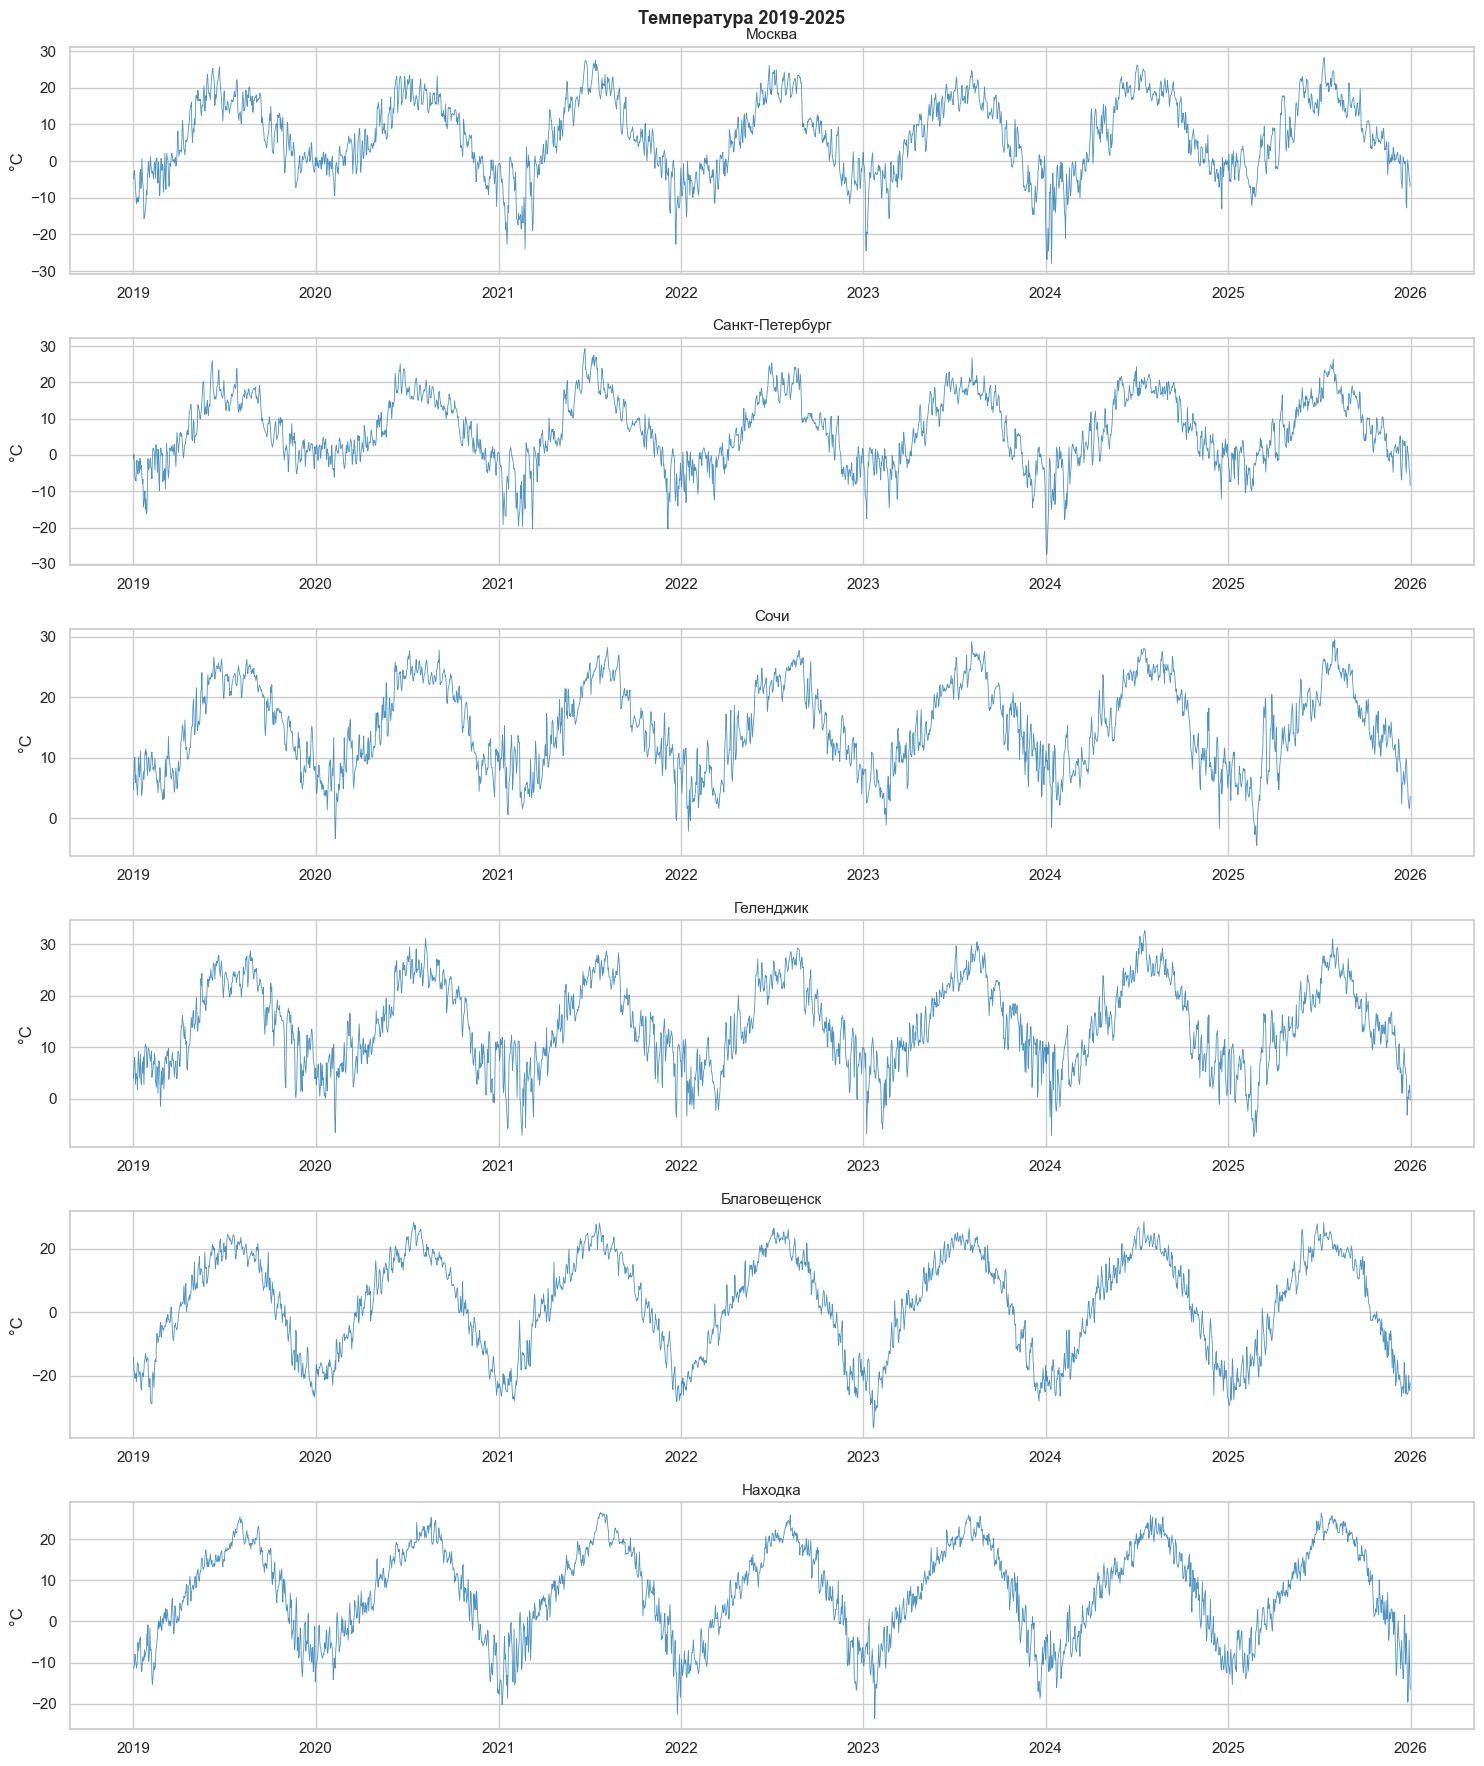

In [158]:
fig, axes = plt.subplots(6, 1, figsize=(15, 18), sharex=False)
for ax, (city, df) in zip(axes, daily.items()):
    ax.plot(df.index, df['temperature_2m'], linewidth=0.6, alpha=0.8)
    ax.set_title(city, fontsize=11)
    ax.set_ylabel('°C')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.suptitle('Температура 2019-2025', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.1.2 Распределения признаков (гистограммы + box-plot)

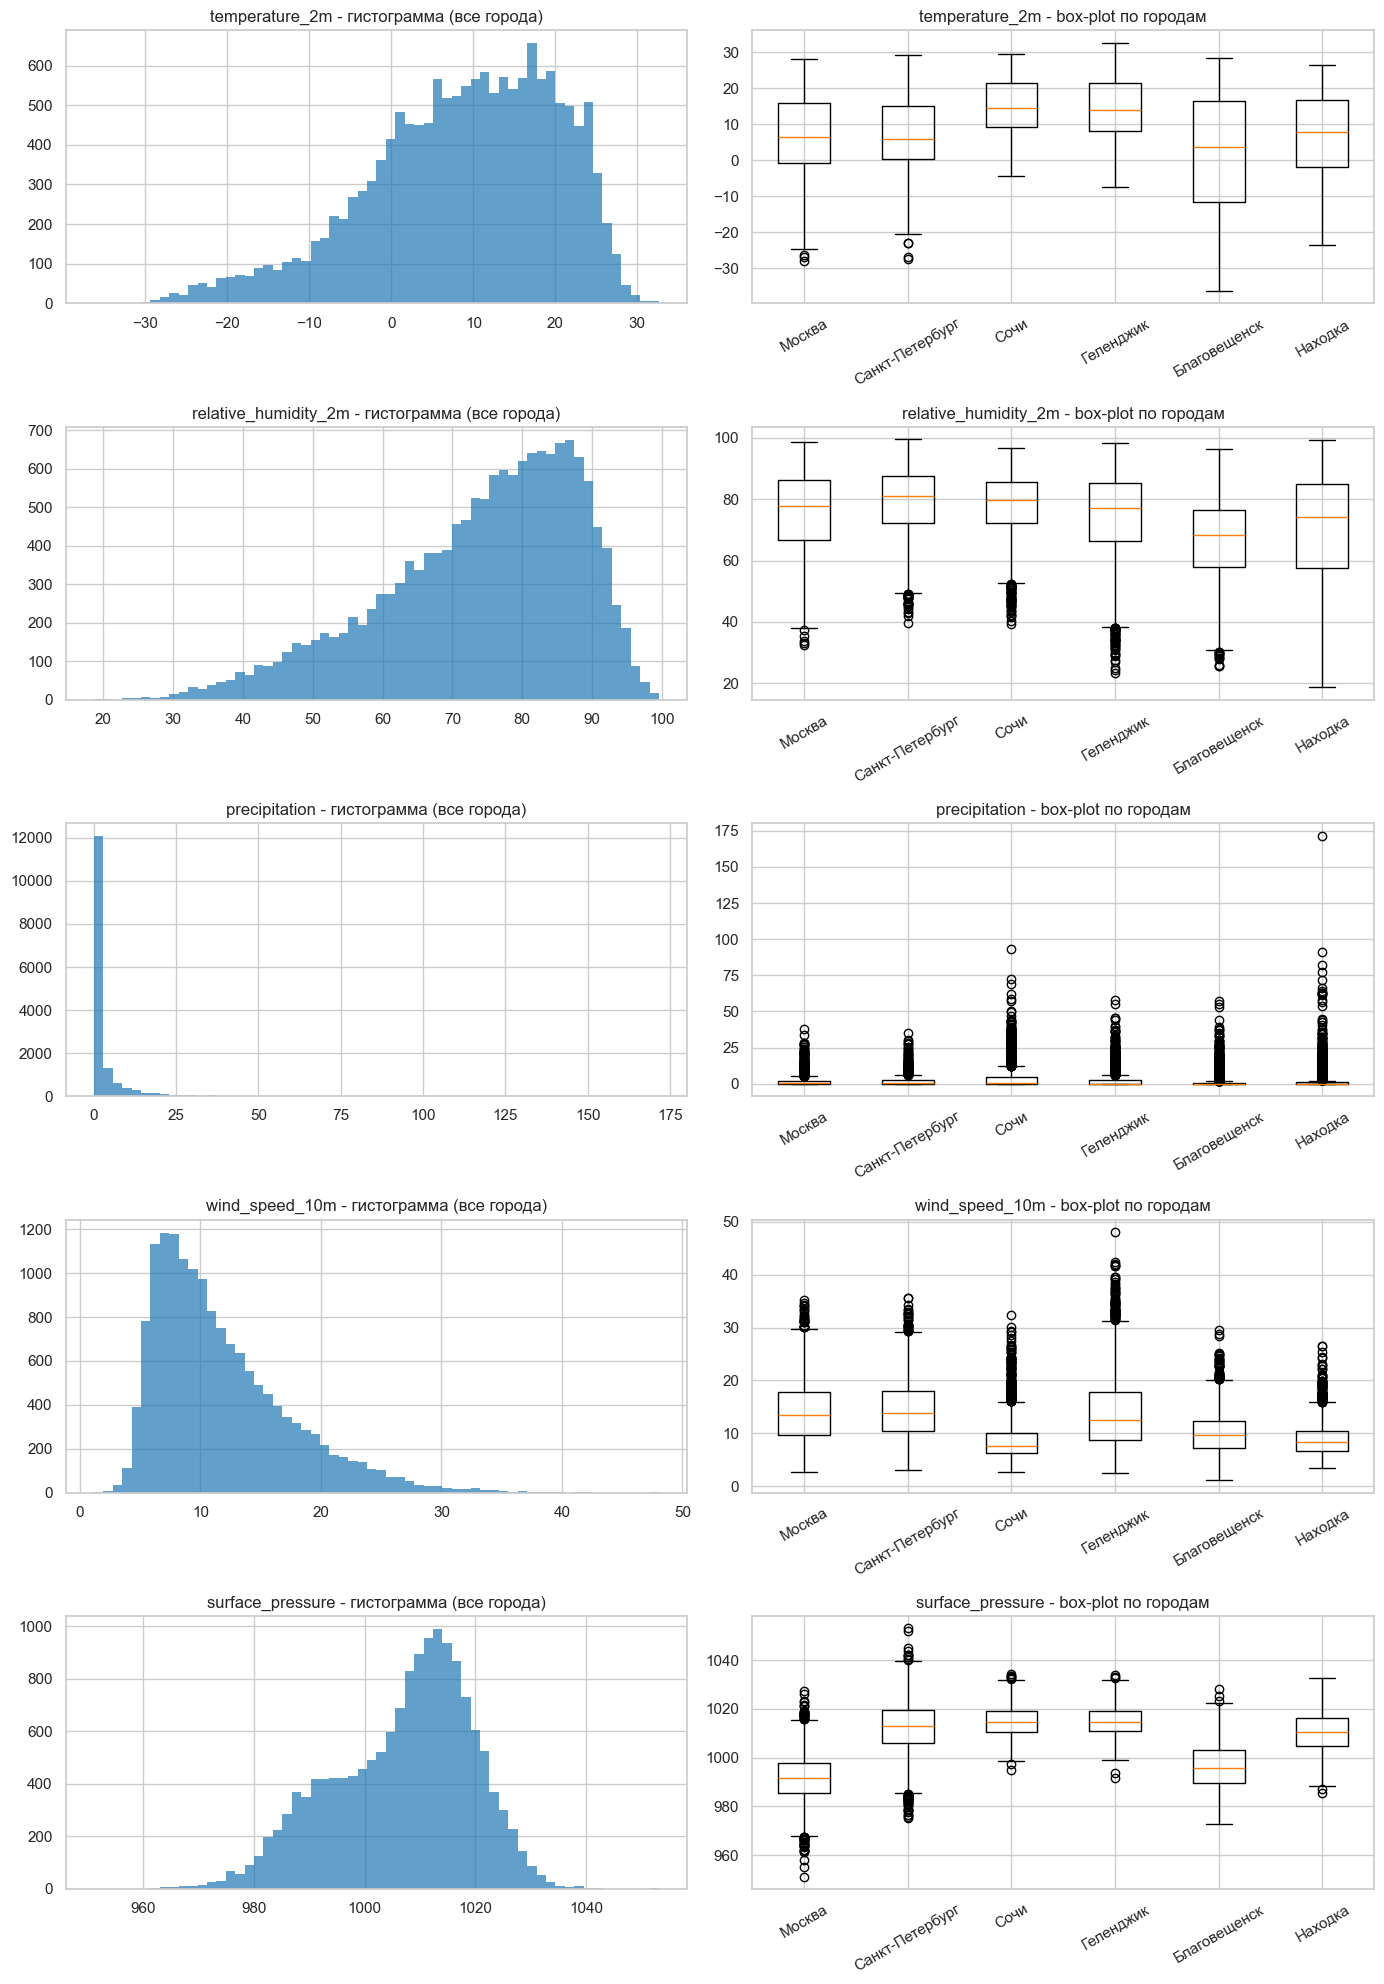

In [157]:
CONT_VARS = ['temperature_2m', 'relative_humidity_2m', 'precipitation',
             'wind_speed_10m', 'surface_pressure']

fig, axes = plt.subplots(len(CONT_VARS), 2, figsize=(14, 4*len(CONT_VARS)))
for i, var in enumerate(CONT_VARS):
    all_vals = pd.concat([df[var].dropna() for df in daily.values()])
    axes[i, 0].hist(all_vals, bins=60, edgecolor='none', alpha=0.7)
    axes[i, 0].set_title(f'{var} - гистограмма (все города)')
    axes[i, 1].boxplot([df[var].dropna().values for df in daily.values()],
                       labels=list(daily.keys()), vert=True)
    axes[i, 1].set_title(f'{var} - box-plot по городам')
    axes[i, 1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

### 2.1.3a Анализ выбросов

In [156]:
outlier_rows = []
for var in CONT_VARS:
    for city, df in daily.items():
        s = df[var].dropna()
        Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
        IQR = Q3 - Q1
        lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        n_out = ((s < lo) | (s > hi)).sum()
        outlier_rows.append({
            'Переменная': var, 'Город': city,
            'N': len(s), 'Выбросов': n_out,
            '%': round(100 * n_out / len(s), 2),
            'Нижн.': round(lo, 2), 'Верхн.': round(hi, 2),
        })

out_df = pd.DataFrame(outlier_rows).set_index(['Переменная', 'Город'])
print('Выбросы по IQR-правилу [Q1 - 1.5·IQR, Q3 + 1.5·IQR]:')
display(out_df.style
        .background_gradient(cmap='YlOrRd', subset=['%'])
        .format({'%': '{:.2f}', 'N': '{:,}', 'Выбросов': '{:,}'}))

Выбросы по IQR-правилу [Q1 - 1.5·IQR, Q3 + 1.5·IQR]:


Стратегия обработки выбросов:

  temperature_2m, relative_humidity_2m, wind_speed_10m, surface_pressure:
    Выбросы - физически реализуемые экстремумы (рекорды t, штормовой ветер,
    глубокие антициклоны). Удаление исказит выборку и ухудшит прогноз
    при опасных явлениях. Стратегия: сохранить без изменений.

  precipitation:
    Правосторонний хвост закономерен - гамма-распределение (много нулей
    в сухие дни, редкие ливневые максимумы). Стратегия: не удалять.

### 2.1.3 Q-Q plot нормальности признаков

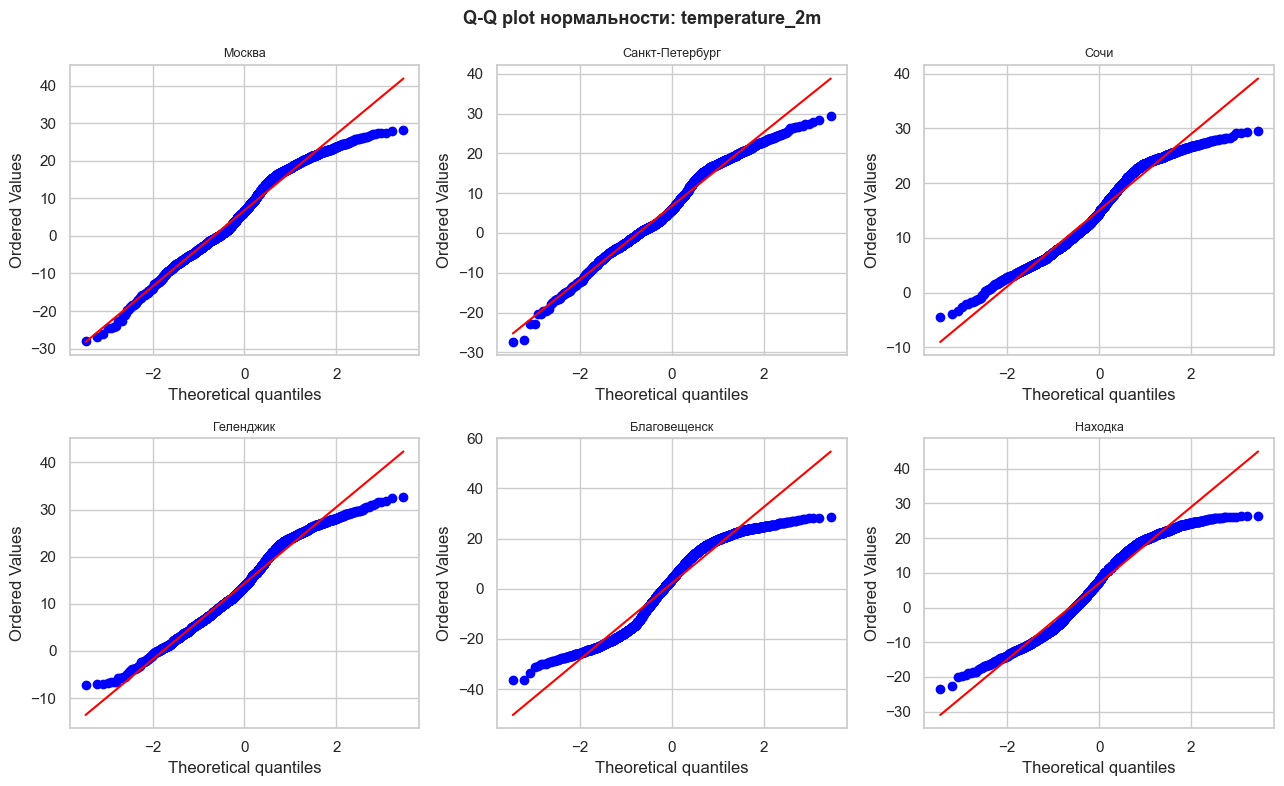

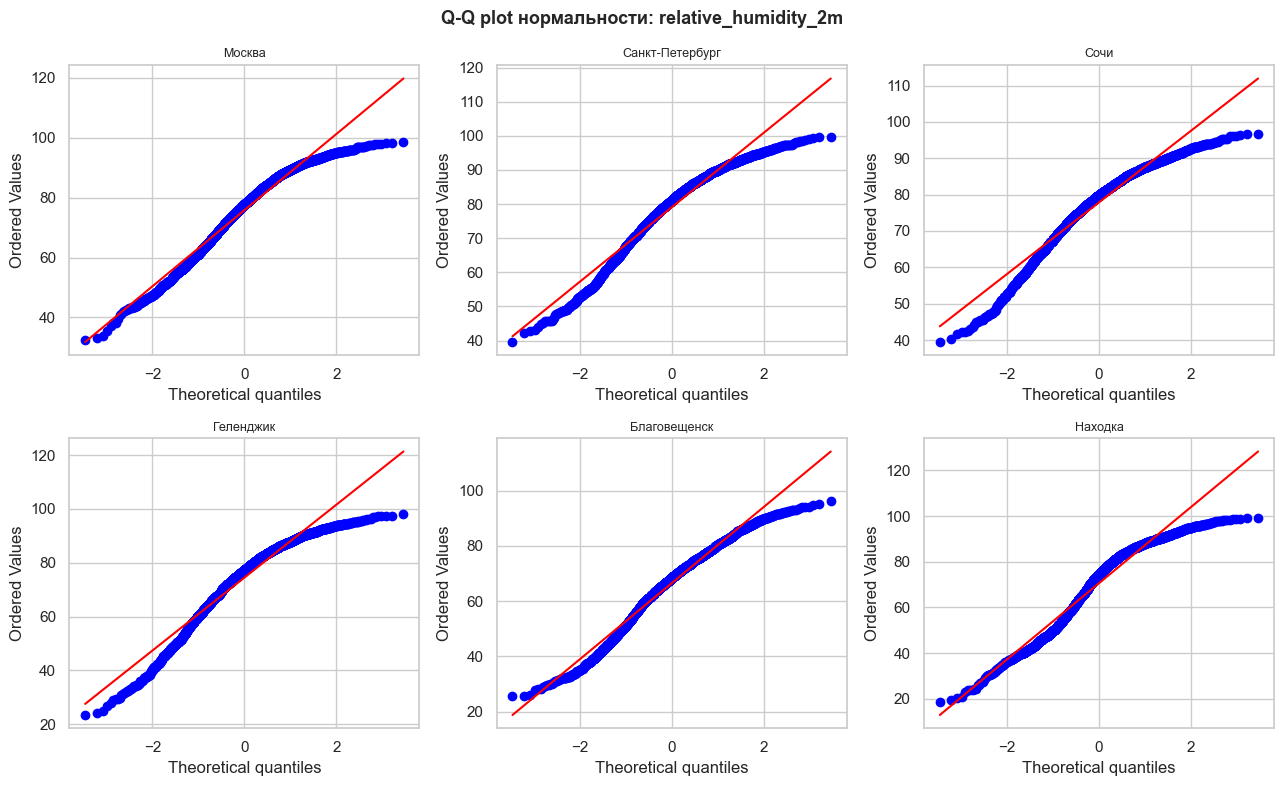

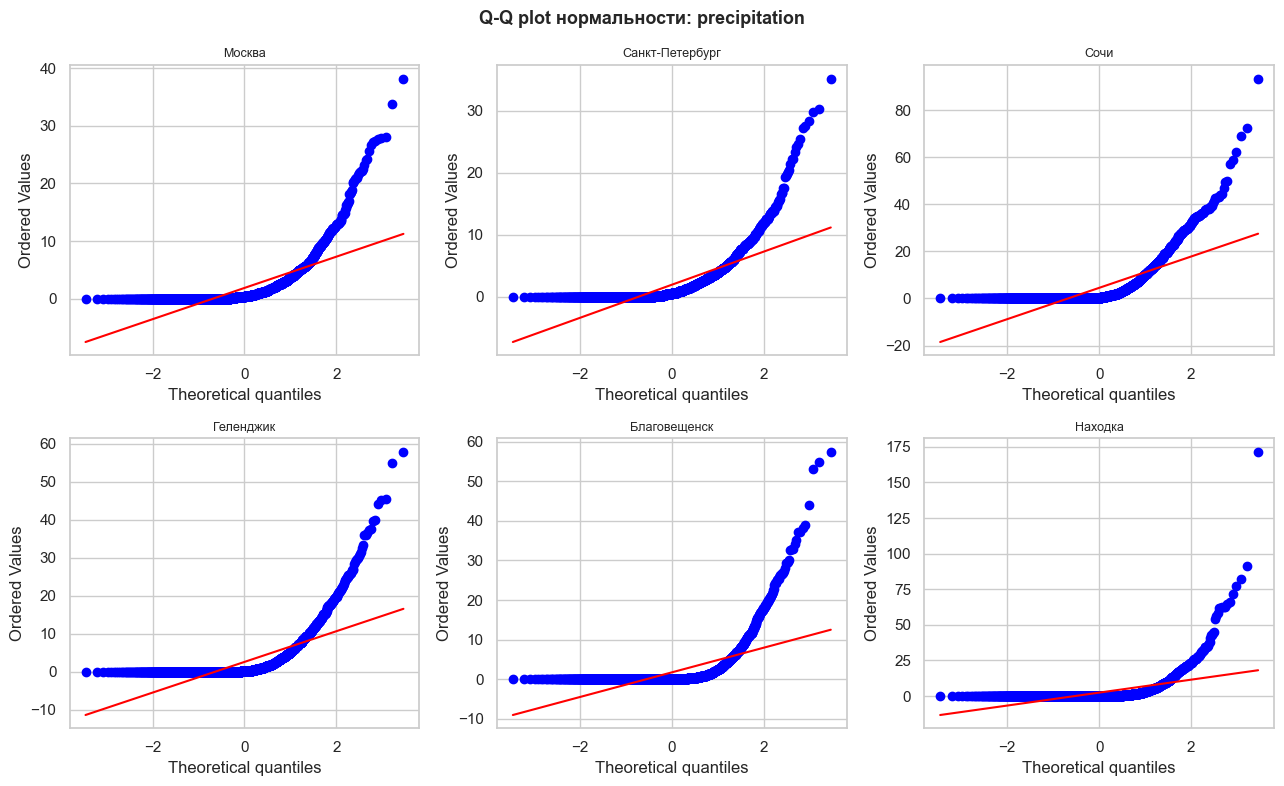

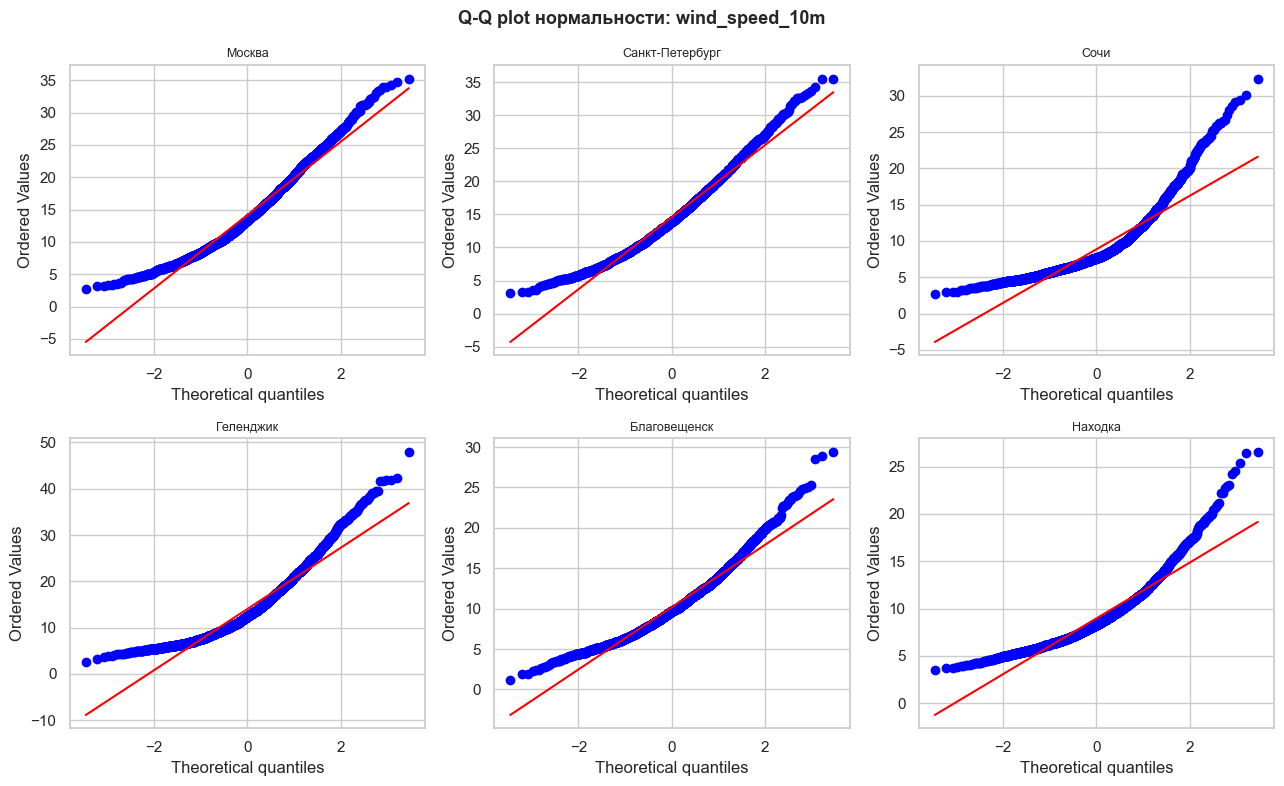

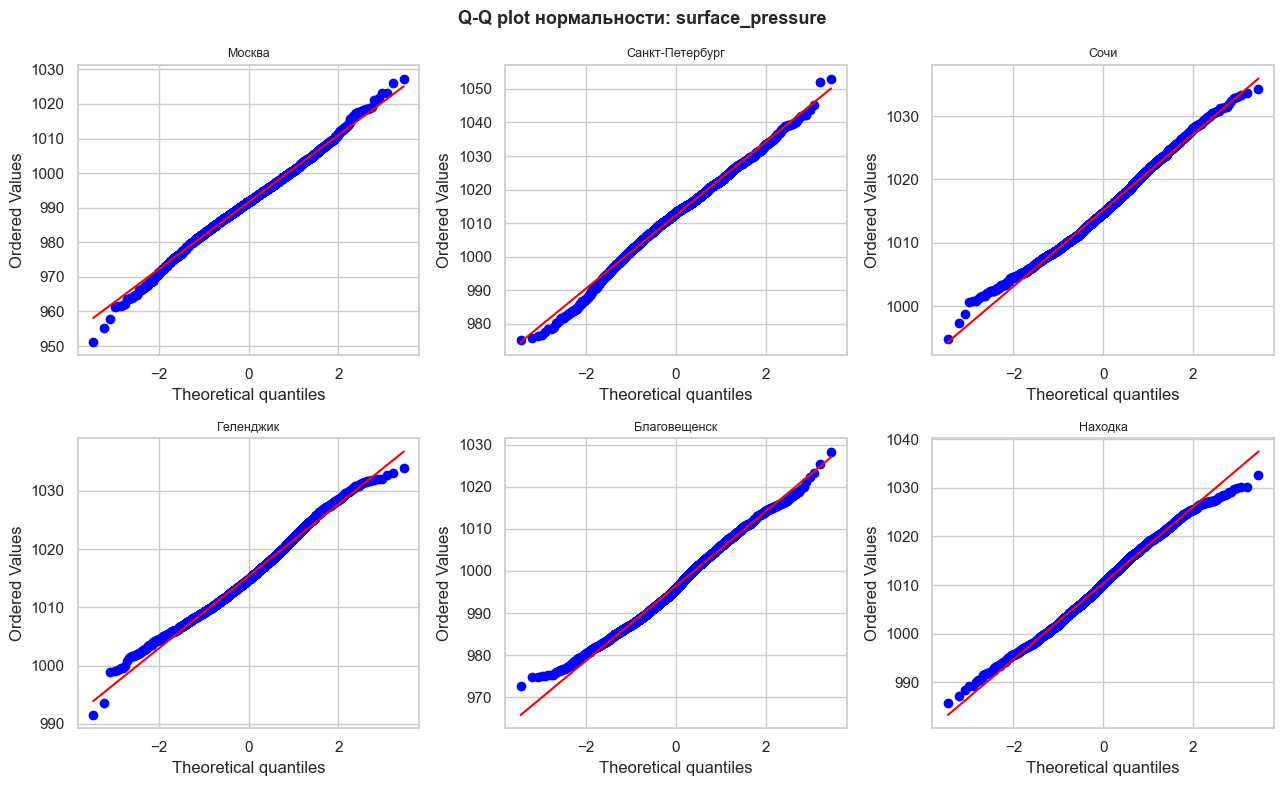

In [127]:
for var in CONT_VARS:
    fig, axes = plt.subplots(2, 3, figsize=(13, 8))
    for ax, (city, df) in zip(axes.flat, daily.items()):
        stats.probplot(df[var].dropna(), dist='norm', plot=ax)
        ax.set_title(city, fontsize=9)
    plt.suptitle(f'Q-Q plot нормальности: {var}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 2.1.4 Сезонные паттерны (среднемесячная температура)

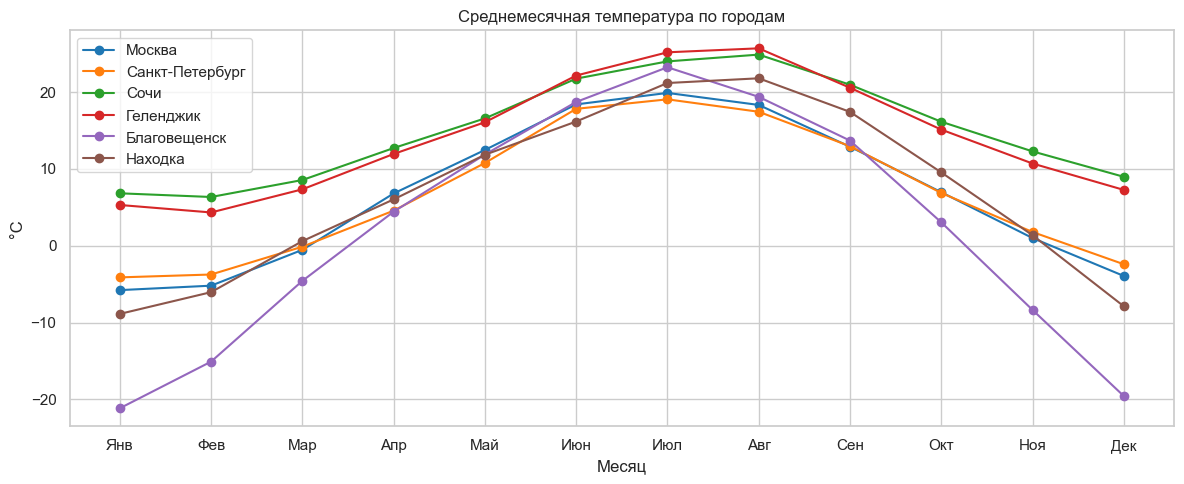

In [128]:
fig, ax = plt.subplots(figsize=(12, 5))
for city, df in daily.items():
    monthly = df['temperature_2m'].groupby(df.index.month).mean()
    ax.plot(monthly.index, monthly.values, marker='o', label=city)
ax.set_xticks(range(1,13))
ax.set_xticklabels(['Янв','Фев','Мар','Апр','Май','Июн',
                    'Июл','Авг','Сен','Окт','Ноя','Дек'])
ax.set_xlabel('Месяц')
ax.set_ylabel('°C')
ax.set_title('Среднемесячная температура по городам')
ax.legend()
plt.tight_layout()
plt.show()

### 2.1.5 Корреляционные матрицы по городам

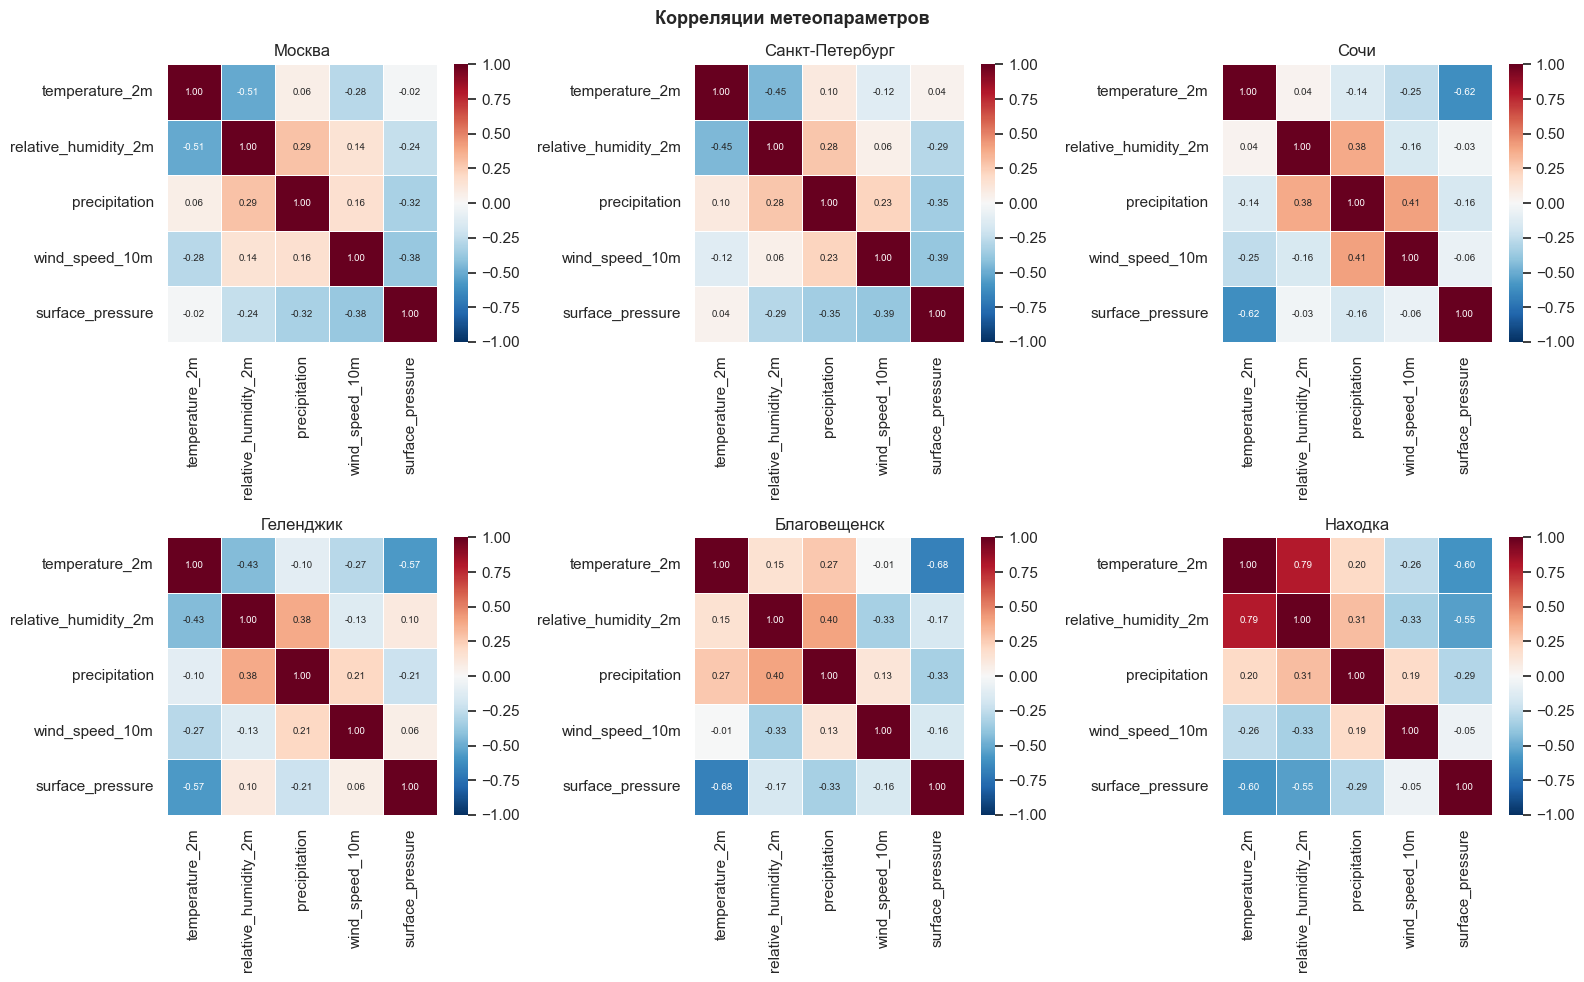

In [129]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, (city, df) in zip(axes.flat, daily.items()):
    corr = df[CONT_VARS].corr()
    sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='RdBu_r',
                vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 7})
    ax.set_title(city)
plt.suptitle('Корреляции метеопараметров', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

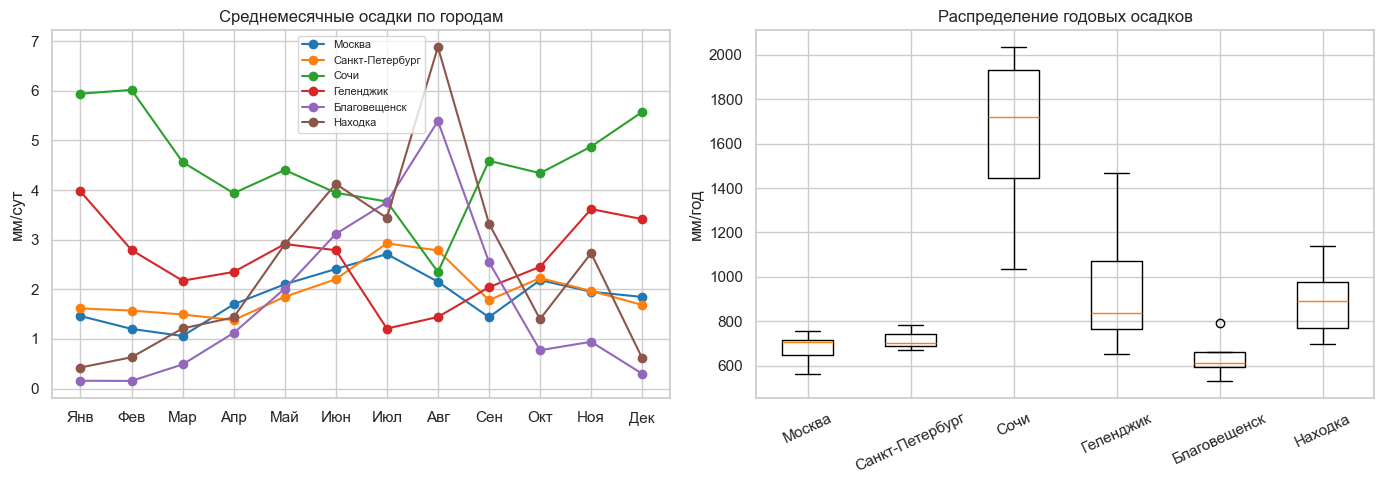

In [130]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for city, df in daily.items():
    monthly_prec = df['precipitation'].groupby(df.index.month).mean()
    axes[0].plot(monthly_prec.index, monthly_prec.values, marker='o', label=city)
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(['Янв','Фев','Мар','Апр','Май','Июн',
                          'Июл','Авг','Сен','Окт','Ноя','Дек'])
axes[0].set_ylabel('мм/сут')
axes[0].set_title('Среднемесячные осадки по городам')
axes[0].legend(fontsize=8)
annual_prec = [daily[city]['precipitation'].resample('YE').sum().values for city in CITIES]
axes[1].boxplot(annual_prec, labels=CITIES, vert=True)
axes[1].set_ylabel('мм/год')
axes[1].set_title('Распределение годовых осадков')
axes[1].tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

### 2.1.6 Анализ пропусков

In [131]:
miss = pd.DataFrame({city: df.isnull().mean() * 100 for city, df in daily.items()}).T
print('Доля пропусков по городам и признакам:')
display(miss.style.background_gradient(cmap='YlOrRd', vmin=0, vmax=10).format('{:.2f}'))

for city in daily:
    daily[city][['temperature_2m','relative_humidity_2m','wind_speed_10m','surface_pressure']] = \
        daily[city][['temperature_2m','relative_humidity_2m','wind_speed_10m','surface_pressure']].interpolate('linear')
    daily[city][['precipitation','rain','snowfall']] = \
        daily[city][['precipitation','rain','snowfall']].fillna(0)
    daily[city]['weathercode'] = daily[city]['weathercode'].ffill()

print('\nПосле обработки пропусков:')
for city, df in daily.items():
    print(f'  {city}: {df.isnull().sum().sum()} пропусков')

Доля пропусков по городам и признакам:


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure
Москва,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Санкт-Петербург,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Сочи,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Геленджик,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Благовещенск,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Находка,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00



После обработки пропусков:
  Москва: 0 пропусков
  Санкт-Петербург: 0 пропусков
  Сочи: 0 пропусков
  Геленджик: 0 пропусков
  Благовещенск: 0 пропусков
  Находка: 0 пропусков


### 2.1.7 Тест Дики-Фуллера (стационарность, все переменные)
**Гипотезы:** H₀ — ряд нестационарен (единичный корень), H₁ — стационарен.  
p < 0.05 → отвергаем H₀ → ряд стационарен.

In [155]:
print(f"{'Переменная':<26} {'Город':<22} {'ADF-stat':>10} {'p-value':>10} {'Вывод'}")
print('-' * 90)
for var in CONT_VARS:
    for city, df in daily.items():
        series = df[var].dropna()
        result = adfuller(series, autolag='AIC')
        stat, p = result[0], result[1]
        conclusion = 'стационарен' if p < 0.05 else 'нестационарен'
        print(f'{var:<26} {city:<22} {stat:>10.3f} {p:>10.4f}   {conclusion}')
    print()

Переменная                 Город                    ADF-stat    p-value Вывод
------------------------------------------------------------------------------------------
temperature_2m             Москва                     -3.158     0.0225   стационарен
temperature_2m             Санкт-Петербург            -3.183     0.0210   стационарен
temperature_2m             Сочи                       -3.098     0.0267   стационарен
temperature_2m             Геленджик                  -3.011     0.0339   стационарен
temperature_2m             Благовещенск               -3.333     0.0135   стационарен
temperature_2m             Находка                    -2.847     0.0519   нестационарен

relative_humidity_2m       Москва                     -5.237     0.0000   стационарен
relative_humidity_2m       Санкт-Петербург            -4.468     0.0002   стационарен
relative_humidity_2m       Сочи                       -8.226     0.0000   стационарен
relative_humidity_2m       Геленджик                  

### Выводы по EDA (раздел 2.1)

По данным: шесть городов за семь лет, 2 557 суточных наблюдений на каждый город (61 368 часовых записей до агрегации). Пропуски отсутствуют — данные open-meteo предварительно интерполированы. Стратегия обработки: линейная интерполяция для непрерывных признаков, заполнение нулями для осадков.

Температурные ряды демонстрируют чёткую годовую сезонность. Амплитуда принципиально различается: наибольшая у Благовещенска (~65°C), наименьшая у Сочи и Геленджика (~30°C). Корреляционный анализ подтверждает физическую интерпретацию: Находка — единственный город, где температура положительно связана с влажностью (r = +0.79), что объясняется тихоокеанским муссоном.

По тесту ADF пять из шести городов стационарны при p < 0.05. Находка пограничная (p = 0.052) — слабый тренд потепления не требует дифференцирования в контексте задачи.

## 2.2 Инжиниринг признаков (для модуля прогнозирования)

Каждая строка `feat` описывает текущее состояние атмосферы одним вектором ~55 признаков, 
которые подаются в LightGBM без явного окна lookback.

### Группы признаков

| Группа | Признаки | Физическое обоснование |
|---|---|---|
| Сезонность | `month_sin/cos`, `doy_sin/cos`, `season` | Температура определяется прежде всего годовым ходом инсоляции |
| Лаги t, p | `temp_lag{1,3,7,14,30}`, `press_lag{1,3,7,14,30}` | Инерция атмосферных масс: синоптические системы живут 1–14 сут., сезонный тренд — до 30 сут. |
| Лаги влажности | `humid_lag{7,14}` | Влажность воздушной массы за 1–2 нед. определяет испарение, облачность и осадки на следующий месяц |
| Лаг ветра | `wind_lag7` | Недельная цикличность циркуляции (синоптические волны ~7 сут.) |
| Скользящее среднее/std/min/max t | `temp_roll{mean,std,min,max}_{7,30}` | Характеризуют текущий температурный режим и его изменчивость |
| Скользящая сумма осадков | `prec_rollsum_{7,30}` | Накопленные осадки за неделю/месяц — индикатор режима увлажнения |
| Скользящее среднее влажности | `humid_rollmean_{7,30}` | Тип воздушной массы (морская/континентальная): влажность > 80% → морской воздух |
| Максимальный порыв ветра | `wind_rollmax_{7,30}` | Максимальный порыв за период — ключевой агрегат для характеристики штормовых событий |
| Производные | `temp_diff1/2`, `press_diff1` | Скорость изменения температуры/давления — предвестники смены погодного режима |
| Амплитуда и осадочные дни | `temp_amp30`, `prec_days_30` | Суточная амплитуда t°C различает континентальный (>15°C) и морской (<8°C) климат |
| Климатическая аномалия | `temp_anomaly`, `temp_climate_norm` | Отклонение от многолетней нормы — сигнал о нетипичном погодном эпизоде |


In [ ]:
def build_features(df):
    df = df.copy()

    # Циклические признаки сезонности
    df['dayofyear'] = df.index.dayofyear
    df['month'] = df.index.month
    df['week'] = df.index.isocalendar().week.astype(int)
    df['season'] = df['month'].map({12:0,1:0,2:0, 3:1,4:1,5:1,
                                    6:2,7:2,8:2, 9:3,10:3,11:3})
    df['month_sin'] = np.sin(2*np.pi*df['month']/12)
    df['month_cos'] = np.cos(2*np.pi*df['month']/12)
    df['doy_sin'] = np.sin(2*np.pi*df['dayofyear']/365.25)
    df['doy_cos'] = np.cos(2*np.pi*df['dayofyear']/365.25)

    # Лаги: температура, давление, влажность, ветер
    for lag in [1, 3, 7, 14, 30]:
        df[f'temp_lag{lag}']  = df['temperature_2m'].shift(lag)
        df[f'press_lag{lag}'] = df['surface_pressure'].shift(lag)
    # Влажность: лаги 7 и 14 дней - при горизонте 30 дней влажность
    # за прошедшую неделю/две недели определяет испарение и осадки вперёд
    for lag in [7, 14]:
        df[f'humid_lag{lag}'] = df['relative_humidity_2m'].shift(lag)
    # Ветер: лаг 7 дней - для захвата недельной цикличности синоптических процессов
    df['wind_lag7'] = df['wind_speed_10m'].shift(7)

    # Скользящие статистики: 7 и 30 дней
    for w in [7, 30]:
        # Температура: полный набор (mean, std, min, max)
        df[f'temp_rollmean_{w}']  = df['temperature_2m'].shift(1).rolling(w).mean()
        df[f'temp_rollstd_{w}']   = df['temperature_2m'].shift(1).rolling(w).std()
        df[f'temp_rollmin_{w}']   = df['temperature_2m'].shift(1).rolling(w).min()
        df[f'temp_rollmax_{w}']   = df['temperature_2m'].shift(1).rolling(w).max()
        # Осадки: сумма (суммарное накопление за период)
        df[f'prec_rollsum_{w}']   = df['precipitation'].shift(1).rolling(w).sum()
        # Влажность: среднее (характеризует тип воздушной массы)
        df[f'humid_rollmean_{w}'] = df['relative_humidity_2m'].shift(1).rolling(w).mean()
        # Ветер: максимум (максимальный порыв за период - ключевой агрег. признак)
        df[f'wind_rollmax_{w}']   = df['wind_speed_10m'].shift(1).rolling(w).max()

    # Производные признаки
    df['temp_diff1']  = df['temperature_2m'].diff(1)
    df['temp_diff2']  = df['temp_diff1'].diff(1)
    df['press_diff1'] = df['surface_pressure'].diff(1)
    # Суточная амплитуда температуры за 30 дней
    df['temp_amp30']   = df['temp_rollmax_30'] - df['temp_rollmin_30']
    # Число дождливых дней за 30 дней (осадки > 1 мм)
    df['prec_days_30'] = (df['precipitation'].shift(1) > 1).rolling(30).sum()

    # Климатическая норма и аномалия
    clim_norm = df.groupby(df.index.dayofyear)['temperature_2m'].transform('mean')
    df['temp_climate_norm'] = clim_norm
    df['temp_anomaly']      = df['temperature_2m'] - clim_norm

    return df.dropna()

feat = {city: build_features(df) for city, df in daily.items()}
print('Признаковые пространства (для прогнозирования):')
for city, df in feat.items():
    print(f'  {city}: {df.shape[1]} признаков, {len(df)} дней')


Признаковые пространства (для прогнозирования):
  Москва: 50 признаков, 2527 дней
  Санкт-Петербург: 50 признаков, 2527 дней
  Сочи: 50 признаков, 2527 дней
  Геленджик: 50 признаков, 2527 дней
  Благовещенск: 50 признаков, 2527 дней
  Находка: 50 признаков, 2527 дней


### 2.2.1 PCA - визуализация разделимости городов

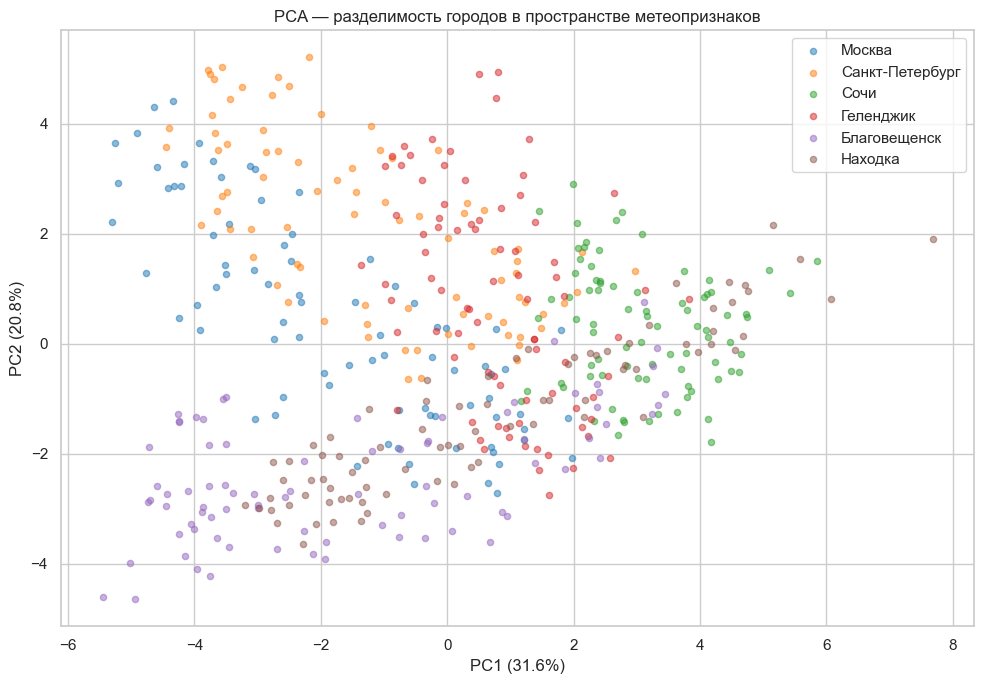

PC1+PC2 объясняют 52.4% дисперсии


In [134]:
clf_rows = []
for city, df in feat.items():
    w = 90
    for start in range(0, len(df) - w, 30):
        chunk = df.iloc[start:start+w]
        row = {'city': city}
        for col in CONT_VARS:
            if col in chunk.columns:
                row[f'{col}_mean'] = chunk[col].mean()
                row[f'{col}_std']  = chunk[col].std()
                row[f'{col}_min']  = chunk[col].min()
                row[f'{col}_max']  = chunk[col].max()
        row['temp_amp']  = chunk['temperature_2m'].max() - chunk['temperature_2m'].min()
        row['prec_days'] = (chunk['precipitation'] > 1).sum()
        row['snow_days'] = (chunk['snowfall'] > 0.1).sum()
        clf_rows.append(row)

clf_df = pd.DataFrame(clf_rows).dropna()
X_clf  = clf_df.drop('city', axis=1).values
y_clf  = clf_df['city'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clf)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
for city in CITIES:
    mask = y_clf == city
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=city, alpha=0.5, s=20)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA — разделимость городов в пространстве метеопризнаков')
ax.legend()
plt.tight_layout()
plt.show()
print(f'PC1+PC2 объясняют {pca.explained_variance_ratio_[:2].sum()*100:.1f}% дисперсии')

### Выводы по Feature Engineering (раздел 2.2)

Признаковое пространство сформировано в объёме **50 признаков** на день для каждого города; после удаления NaN от лагов и скользящих статистик (максимальный лаг 30 дней) осталось **2 527 наблюдений** из 2 557 (потеря ~1.2%).

Данный модуль используется исключительно прогнозирующей частью пайплайна. Классификационный модуль (раздел 2.3) работает с сырыми многомерными рядами напрямую — TSFresh извлекает признаки автоматически внутри `TSFreshClassifier`.

PCA: первые две компоненты объясняют **52.4% дисперсии**. Пары Сочи/Геленджик и Москва/Санкт-Петербург существенно перекрываются — линейная разделимость ограничена, что обосновывает применение специализированных нелинейных TSC-методов.


## 2.3 Классификация временных рядов: TSFresh + специализированные TSC-классификаторы

### Физическое обоснование длины окна (WINDOW_LEN = 90 дней)

Длина окна выбирается из трёх конкурирующих масштабов:

| Вариант | Масштаб | Почему не подходит / почему выбран |
|---|---|---|
| **30 дней** | Синоптический | Охватывает только один тип погоды. Сочи в январе и Сочи в июле неразличимы от Москвы в сходный месяц — сезонная подпись отсутствует. Классификатор видит «мгновенный снимок», а не климат. |
| **90 дней** | Один метеорологический сезон | **Выбранный вариант.** За 90 дней температурный ряд содержит полную форму сезонного хода: начало, пик, спад. Это паттерн, который отличает субтропический Сочи (t_зима ≈ +8°C, малая амплитуда) от континентальной Москвы (t_зима ≈ −7°C, большая амплитуда). TSFresh извлекает автокорреляции, пики и энтропию по всем 90 точкам — климатическая зона раскодируется однозначно. |
| **180 дней** | Полусезон (два сезона) | Окно перекрывает два разных сезона, «усредняя» климатический сигнал. Кроме того, при шаге 30 дней число обучающих образцов сокращается вдвое, что критично для TSFresh с тысячами признаков. |

**Шаг скользящего окна — 30 дней** соответствует синоптическому масштабу: каждый следующий образец начинается с нового синоптического эпизода, что минимизирует дублирование информации между соседними окнами.

---

### Архитектура классификаторов

Задача формулируется как классификация многомерного временного ряда целиком. Модель получает на вход 
последовательность вида `(n_channels, n_timepoints)` — 7 метеоканалов за 90 дней — и определяет климатический регион.

В данной работе используются два специализированных классификатора временных рядов на основе TSFresh из библиотеки `aeon`:

#### TSFreshClassifier + Ridge Classifier
**Архитектура:**
1. **TSFresh-трансформер** — автоматически извлекает сотни статистических характеристик из каждого канала: среднее, дисперсию, автокорреляции при различных лагах, количество пиков, энтропию, спектральные коэффициенты, линейный тренд и др. (EfficientFCParameters ≈ 800 типов × 7 каналов).
2. **FRESH-отбор** (Scalable Hypothesis tests) — тест Краскела–Уоллиса + поправка Бенджамини–Хохберга (FDR < 0.05) оставляет только статистически значимые дискриминаторы.
3. **Ridge Classifier** — линейный классификатор, канонически используемый в TSC-бенчмарках совместно с TSFresh (именно такая пара представлена в оригинальной статье Kanter & Veeramachaneni, 2015, и в UCR/UEA бенчмарках). Ridge устойчив к высокой размерности признакового пространства.

#### FreshPRINCEClassifier
**Fresh Probabilistic and Interpretable Non-linear Classifier Extension** — улучшенная версия TSFreshClassifier, предложенная в статье *FreshPRINCE: A Simple Transformation Based Pipeline Time Series Classifier* (Middlehurst et al., 2022). Отличие: вместо Ridge используется **RotationForest** — ансамблевый метод, специально разработанный для классификации признаковых пространств высокой размерности.

**Почему не бустинг / не Random Forest:**  
Gradient Boosting и стандартный Random Forest — общецелевые tabular-классификаторы. Ridge Classifier и RotationForest выбраны как классификаторы, оптимизированные именно для TSFresh-признакового пространства по результатам TSC-бенчмарков (Bagnall et al., 2017; Middlehurst et al., 2022).

**Входной формат:** `X.shape = (n_samples, n_channels, n_timepoints)`  
**Длина окна:** 90 дней (один метеорологический сезон), **шаг:** 30 дней.


In [ ]:
WINDOW_LEN = 90
STEP       = 30

TS_CHANNELS = [
    'temperature_2m', 'relative_humidity_2m', 'precipitation',
    'rain', 'snowfall', 'wind_speed_10m', 'surface_pressure'
]

# Глобальные статистики по всем городам — нормировка сохраняет межгородские различия
_all_ts = np.concatenate([daily[c][TS_CHANNELS].values for c in CITIES], axis=0)
GLOBAL_MEAN = _all_ts.mean(axis=0)
GLOBAL_STD  = _all_ts.std(axis=0) + 1e-8

def make_ts_dataset(daily_dict, window=WINDOW_LEN, step=STEP):
    '''
    Нарезает суточные ряды на окна.
    X: (n_samples, n_channels, window)  —  формат aeon/sklearn TSC
    y: (n_samples,)
    '''
    X_list, y_list = [], []
    for city, df in daily_dict.items():
        arr = df[TS_CHANNELS].values
        arr = (arr - GLOBAL_MEAN) / GLOBAL_STD  # глобальная нормировка по всем городам
        n = len(arr)
        for start in range(0, n - window, step):
            X_list.append(arr[start:start + window].T)  # (n_channels, window)
            y_list.append(city)
    return np.array(X_list, dtype=np.float32), np.array(y_list)

print('Формирование датасета временных рядов...')
X_ts, y_ts = make_ts_dataset(daily)
print(f'X shape: {X_ts.shape}  →  (образцы, каналы, длина ряда)')
print(f'Нормировка: глобальная (μ температуры = {GLOBAL_MEAN[0]:.1f}°C, σ = {GLOBAL_STD[0]:.1f}°C)')

le_ts = LabelEncoder()
y_enc = le_ts.fit_transform(y_ts)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_ts, y_enc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_enc
)
print(f'Train: {len(X_tr)}, Test: {len(X_te)}')
print(f'Классы: {le_ts.classes_}')

Формирование датасета временных рядов...
X shape: (498, 7, 90)  →  (образцы, каналы, длина ряда)
Нормировка: глобальная (μ температуры = 8.7°C, σ = 11.6°C)
Train: 398, Test: 100
Классы: ['Благовещенск' 'Геленджик' 'Москва' 'Находка' 'Санкт-Петербург' 'Сочи']


In [136]:
print('Обучение TSFreshClassifier + RidgeClassifierCV...')
print('EfficientFCParameters: ожидаемое время 5–15 минут')
print('Для быстрой проверки замените "efficient" на "minimal"')

tsfresh_clf = TSFreshClassifier(
    default_fc_parameters='efficient',
    relevant_feature_extractor=True,
    estimator=RidgeClassifierCV(alphas=np.logspace(-3, 3, 10)),
    n_jobs=-1,
    random_state=RANDOM_STATE
)
tsfresh_clf.fit(X_tr, y_tr)
y_pred_tsfresh = tsfresh_clf.predict(X_te)

print('\n=== TSFreshClassifier + Ridge ===')
print(classification_report(y_te, y_pred_tsfresh, target_names=le_ts.classes_))
print(f'Accuracy: {accuracy_score(y_te, y_pred_tsfresh):.4f}')

Обучение TSFreshClassifier + RidgeClassifierCV...
EfficientFCParameters: ожидаемое время 5–15 минут
Для быстрой проверки замените "efficient" на "minimal"

=== TSFreshClassifier + Ridge ===
                 precision    recall  f1-score   support

   Благовещенск       0.42      0.31      0.36        16
      Геленджик       0.00      0.00      0.00        16
         Москва       0.00      0.00      0.00        17
        Находка       0.00      0.00      0.00        17
Санкт-Петербург       0.20      0.76      0.32        17
           Сочи       0.33      0.06      0.10        17

       accuracy                           0.19       100
      macro avg       0.16      0.19      0.13       100
   weighted avg       0.16      0.19      0.13       100

Accuracy: 0.1900


In [137]:
if HAS_FRESHPRINCE:
    print('Обучение FreshPRINCEClassifier (TSFresh + RotationForest)...')
    fresh_prince = FreshPRINCEClassifier(
        default_fc_parameters='efficient',
        n_estimators=200,
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
    fresh_prince.fit(X_tr, y_tr)
    y_pred_fp = fresh_prince.predict(X_te)

    print('\n=== FreshPRINCEClassifier ===')
    print(classification_report(y_te, y_pred_fp, target_names=le_ts.classes_))
    print(f'Accuracy: {accuracy_score(y_te, y_pred_fp):.4f}')
else:
    print('FreshPRINCEClassifier недоступен. Используем TSFreshClassifier с n_jobs=-1.')
    y_pred_fp = y_pred_tsfresh

Обучение FreshPRINCEClassifier (TSFresh + RotationForest)...

=== FreshPRINCEClassifier ===
                 precision    recall  f1-score   support

   Благовещенск       0.30      0.38      0.33        16
      Геленджик       0.33      0.06      0.11        16
         Москва       0.00      0.00      0.00        17
        Находка       0.03      0.06      0.04        17
Санкт-Петербург       0.08      0.18      0.11        17
           Сочи       0.00      0.00      0.00        17

       accuracy                           0.11       100
      macro avg       0.12      0.11      0.10       100
   weighted avg       0.12      0.11      0.10       100

Accuracy: 0.1100


In [ ]:
from sklearn.model_selection import TimeSeriesSplit

_win_dates = []
for city, df in daily.items():
    n = len(df)
    for start in range(0, n - WINDOW_LEN, STEP):
        _win_dates.append(df.index[start])

_sort_idx      = np.argsort(_win_dates)
X_ts_t         = X_ts[_sort_idx]
y_enc_t        = y_enc[_sort_idx]
_sorted_dates  = np.array(_win_dates)[_sort_idx]

tscv = TimeSeriesSplit(n_splits=5)
print('TimeSeriesSplit(n_splits=5) — границы фолдов:')
for i, (tr, te) in enumerate(tscv.split(X_ts_t)):
    d_tr = f'{_sorted_dates[tr[0]].date()} – {_sorted_dates[tr[-1]].date()}'
    d_te = f'{_sorted_dates[te[0]].date()} – {_sorted_dates[te[-1]].date()}'
    print(f'  Fold {i+1}: train [{d_tr}] n={len(tr)},  test [{d_te}] n={len(te)}')

print('\nКросс-валидация TSFreshClassifier + Ridge...')
cv_scores = cross_val_score(
    TSFreshClassifier(
        default_fc_parameters='efficient',
        relevant_feature_extractor=True,
        estimator=RidgeClassifierCV(alphas=np.logspace(-3, 3, 10)),
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),
    X_ts_t, y_enc_t, cv=tscv, scoring='accuracy', n_jobs=1
)
print(f'TSFresh+Ridge  CV Accuracy: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
print(f'По фолдам: {np.round(cv_scores, 4)}')

if HAS_FRESHPRINCE:
    print('\nКросс-валидация FreshPRINCEClassifier...')
    cv_fp = cross_val_score(
        FreshPRINCEClassifier(
            default_fc_parameters='efficient',
            n_estimators=200,
            n_jobs=-1,
            random_state=RANDOM_STATE
        ),
        X_ts_t, y_enc_t, cv=tscv, scoring='accuracy', n_jobs=1
    )
    print(f'FreshPRINCE    CV Accuracy: {cv_fp.mean():.4f} +/- {cv_fp.std():.4f}')
    print(f'По фолдам: {np.round(cv_fp, 4)}')

TimeSeriesSplit(n_splits=5) — границы фолдов:
  Fold 1: train [2019-01-01 – 2020-01-26] n=83,  test [2020-01-26 – 2021-03-21] n=83
  Fold 2: train [2019-01-01 – 2021-03-21] n=166,  test [2021-03-21 – 2022-05-15] n=83
  Fold 3: train [2019-01-01 – 2022-05-15] n=249,  test [2022-05-15 – 2023-07-09] n=83
  Fold 4: train [2019-01-01 – 2023-07-09] n=332,  test [2023-07-09 – 2024-09-01] n=83
  Fold 5: train [2019-01-01 – 2024-09-01] n=415,  test [2024-09-01 – 2025-09-26] n=83

Кросс-валидация TSFreshClassifier + Ridge...
TSFresh+Ridge  CV Accuracy: 0.5325 +/- 0.3097
По фолдам: [0.2289 0.8916 0.9277 0.2892 0.3253]

Кросс-валидация FreshPRINCEClassifier...
FreshPRINCE    CV Accuracy: 0.4771 +/- 0.3528
По фолдам: [0.1687 0.253  0.9759 0.1566 0.8313]


## 2.4 Оценка качества классификации

In [ ]:
rows = [
    {
        'Метод': 'TSFreshClassifier + Ridge',
        'Accuracy': accuracy_score(y_te, y_pred_tsfresh),
        'F1-macro': f1_score(y_te, y_pred_tsfresh, average='macro'),
        'F1-weighted': f1_score(y_te, y_pred_tsfresh, average='weighted'),
        'Precision-macro': precision_score(y_te, y_pred_tsfresh, average='macro'),
        'Recall-macro': recall_score(y_te, y_pred_tsfresh, average='macro'),
    },
]
if HAS_FRESHPRINCE and not np.array_equal(y_pred_fp, y_pred_tsfresh):
    rows.append({
        'Метод': 'FreshPRINCEClassifier',
        'Accuracy': accuracy_score(y_te, y_pred_fp),
        'F1-macro': f1_score(y_te, y_pred_fp, average='macro'),
        'F1-weighted': f1_score(y_te, y_pred_fp, average='weighted'),
        'Precision-macro': precision_score(y_te, y_pred_fp, average='macro'),
        'Recall-macro': recall_score(y_te, y_pred_fp, average='macro'),
    })

metrics_tsc = pd.DataFrame(rows).set_index('Метод')
display(metrics_tsc.style.format('{:.4f}').highlight_max(axis=0, color='lightgreen'))

,Accuracy,F1-macro,F1-weighted,Precision-macro,Recall-macro
Метод,,,,,
TSFreshClassifier + Ridge,0.1900,0.1297,0.1287,0.1589,0.1893
FreshPRINCEClassifier,0.1100,0.0980,0.0956,0.1238,0.1121


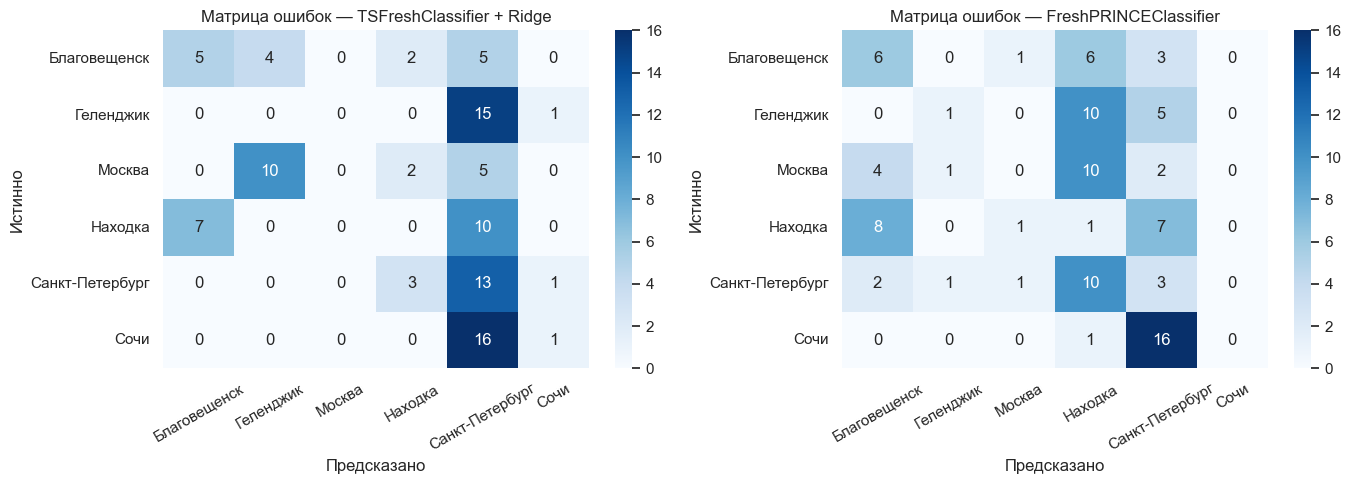

In [140]:
n_models = 2 if (HAS_FRESHPRINCE and not np.array_equal(y_pred_fp, y_pred_tsfresh)) else 1
fig, axes = plt.subplots(1, n_models, figsize=(7*n_models, 5))
if n_models == 1:
    axes = [axes]

pairs = [('TSFreshClassifier + Ridge', y_pred_tsfresh)]
if n_models == 2:
    pairs.append(('FreshPRINCEClassifier', y_pred_fp))

for ax, (name, pred) in zip(axes, pairs):
    cm = confusion_matrix(y_te, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le_ts.classes_, yticklabels=le_ts.classes_, ax=ax)
    ax.set_xlabel('Предсказано')
    ax.set_ylabel('Истинно')
    ax.set_title(f'Матрица ошибок — {name}')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
# ROC-AUC
try:
    proba_tsfresh = tsfresh_clf.predict_proba(X_te)
    roc_tsfresh = roc_auc_score(y_te, proba_tsfresh, multi_class='ovr', average='macro')
    print(f'TSFreshClassifier+Ridge  ROC-AUC (macro, OvR): {roc_tsfresh:.4f}')
except Exception as e:
    print(f'ROC-AUC недоступен: {e}')

if HAS_FRESHPRINCE and not np.array_equal(y_pred_fp, y_pred_tsfresh):
    try:
        proba_fp = fresh_prince.predict_proba(X_te)
        roc_fp = roc_auc_score(y_te, proba_fp, multi_class='ovr', average='macro')
        print(f'FreshPRINCEClassifier    ROC-AUC (macro, OvR): {roc_fp:.4f}')
    except Exception as e:
        print(f'FreshPRINCE ROC-AUC недоступен: {e}')

# Сезонный анализ ошибок
season_names = {0: 'Зима', 1: 'Весна', 2: 'Лето', 3: 'Осень'}
rows_meta = []
for city, df in daily.items():
    n = len(df)
    for start in range(0, n - WINDOW_LEN, STEP):
        mid = df.index[start + WINDOW_LEN // 2]
        rows_meta.append({'city': city, 'month': mid.month, 'year': mid.year,
                          'season': (mid.month % 12) // 3,
                          'date': mid})
meta_df = pd.DataFrame(rows_meta)
y_enc_all = le_ts.transform(meta_df['city'].values)
idx_all = np.arange(len(meta_df))
_, idx_test_meta = train_test_split(idx_all, test_size=0.2, random_state=42,
                                    stratify=y_enc_all)
meta_test = meta_df.iloc[idx_test_meta].copy()
meta_test['pred'] = le_ts.inverse_transform(y_pred_tsfresh)
meta_test['correct'] = meta_test['city'] == meta_test['pred']
season_acc = meta_test.groupby('season')['correct'].mean()
print('\nТочность TSFreshClassifier+Ridge по сезонам:')
for s, acc in season_acc.items():
    print(f'  {season_names[s]}: {acc:.3f}')

TSFreshClassifier+Ridge  ROC-AUC (macro, OvR): 0.5136
FreshPRINCEClassifier    ROC-AUC (macro, OvR): 0.5325

Точность TSFreshClassifier+Ridge по сезонам:
  Зима: 0.107
  Весна: 0.227
  Лето: 0.235
  Осень: 0.212


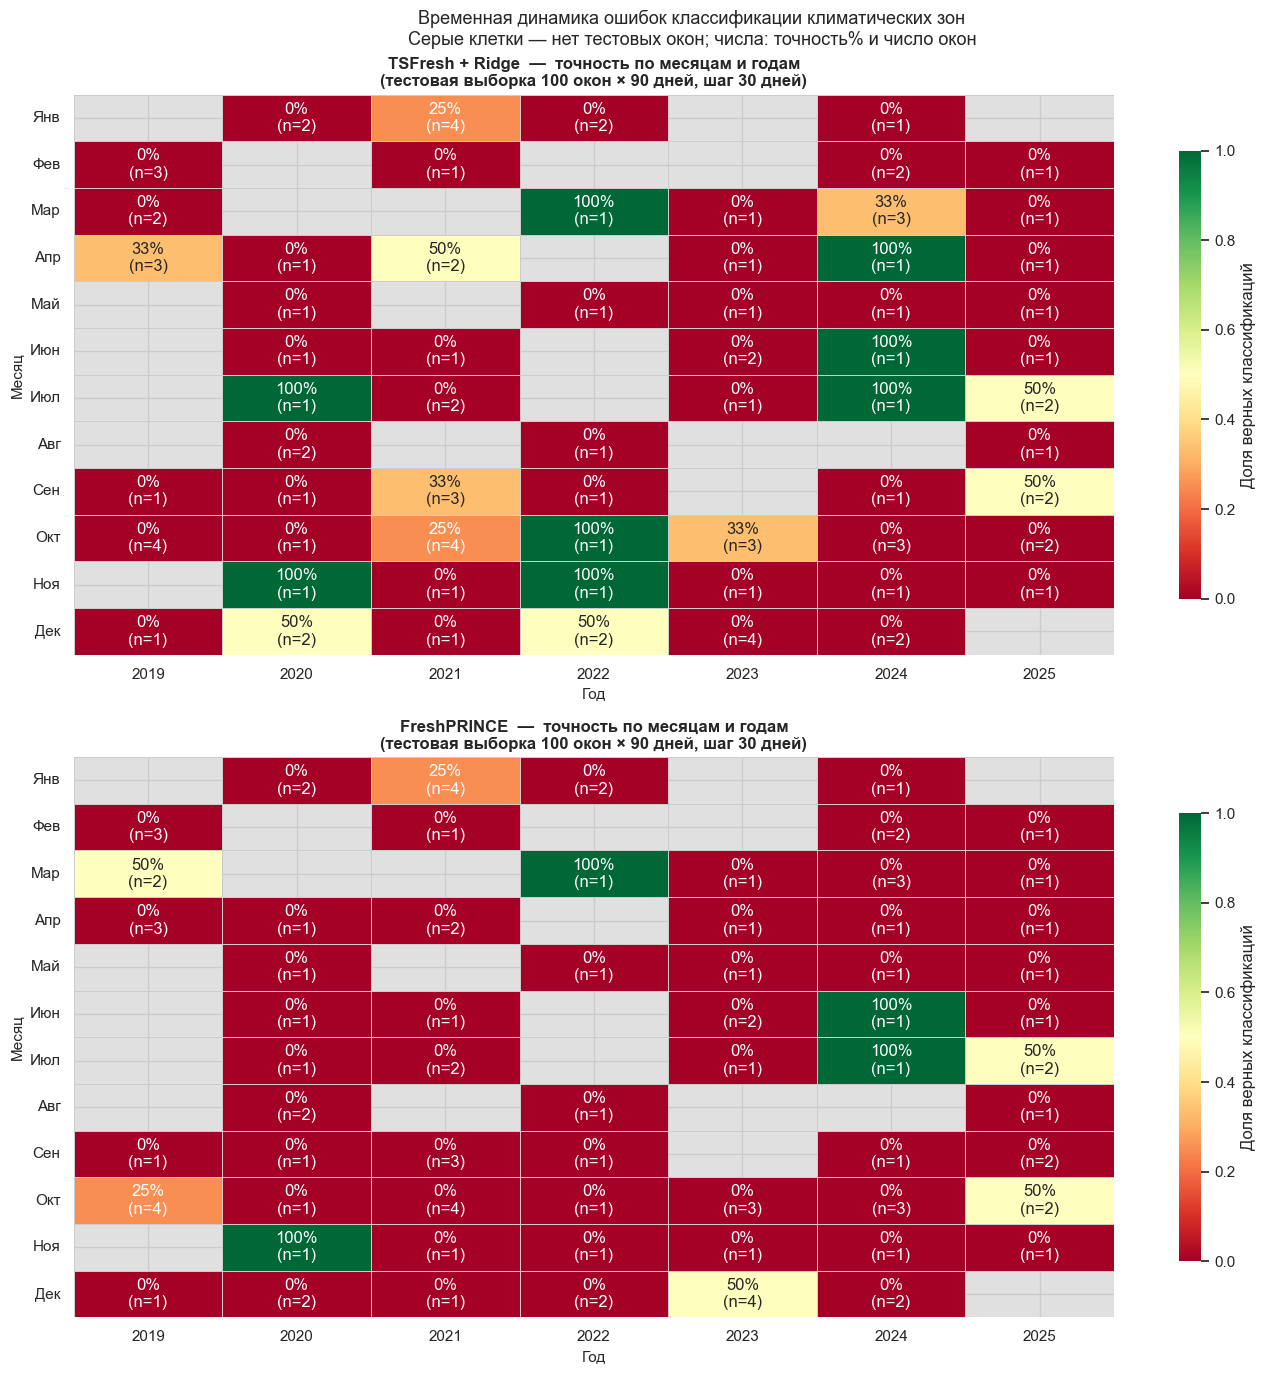

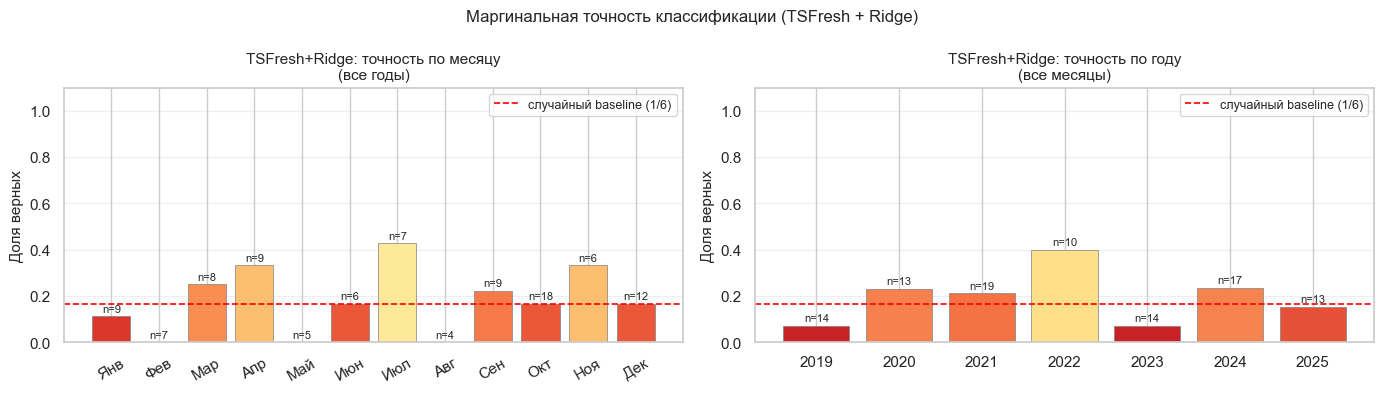

In [ ]:
month_labels = ['Янв','Фев','Мар','Апр','Май','Июн',
                'Июл','Авг','Сен','Окт','Ноя','Дек']
all_years  = sorted(meta_test['year'].unique())
all_months = list(range(1, 13))

models_to_plot = [('TSFresh + Ridge', 'correct')]
if HAS_FRESHPRINCE and not np.array_equal(y_pred_fp, y_pred_tsfresh):
    meta_test = meta_test.copy()
    meta_test['correct_fp'] = (le_ts.inverse_transform(y_pred_fp) ==
                               meta_test['city'].values)
    models_to_plot.append(('FreshPRINCE', 'correct_fp'))

n_models = len(models_to_plot)
fig, axes = plt.subplots(n_models, 1, figsize=(14, 7 * n_models))
if n_models == 1:
    axes = [axes]

for ax, (model_name, col) in zip(axes, models_to_plot):
    pivot = (meta_test
             .pivot_table(values=col, index='month', columns='year', aggfunc='mean')
             .reindex(index=all_months, columns=all_years))
    counts = (meta_test
              .pivot_table(values=col, index='month', columns='year', aggfunc='count')
              .reindex(index=all_months, columns=all_years))

    annots = []
    for mi in all_months:
        row = []
        for yr in all_years:
            v  = pivot.at[mi, yr]  if (mi in pivot.index  and yr in pivot.columns)  else float('nan')
            n  = counts.at[mi, yr] if (mi in counts.index and yr in counts.columns) else float('nan')
            if v != v:   # NaN
                row.append('')
            else:
                row.append(f'{v:.0%}\n(n={int(n)})')
        annots.append(row)

    sns.heatmap(
        pivot, ax=ax,
        annot=annots, fmt='',
        cmap='RdYlGn', vmin=0, vmax=1,
        linewidths=0.6, linecolor='#cccccc',
        mask=pivot.isna(),
        cbar_kws={'label': 'Доля верных классификаций', 'shrink': 0.8},
        xticklabels=all_years,
        yticklabels=month_labels,
    )
    ax.patch.set_facecolor('#e0e0e0')

    ax.set_title(f'{model_name}  —  точность по месяцам и годам\n'
                 f'(тестовая выборка {len(meta_test)} окон × 90 дней, шаг 30 дней)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Год', fontsize=11)
    ax.set_ylabel('Месяц', fontsize=11)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle(
    'Временная динамика ошибок классификации климатических зон\n'
    'Серые клетки — нет тестовых окон; числа: точность% и число окон',
    fontsize=13)
plt.tight_layout()
plt.show()

fig2, (ax_m, ax_y) = plt.subplots(1, 2, figsize=(14, 4))

# по месяцу
month_acc   = meta_test.groupby('month')['correct'].mean()
month_count = meta_test.groupby('month')['correct'].count()
bars = ax_m.bar(month_acc.index, month_acc.values,
                color=[plt.cm.RdYlGn(v) for v in month_acc.values],
                edgecolor='grey', linewidth=0.5)
for bar, cnt in zip(bars, month_count.values):
    ax_m.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
              f'n={cnt}', ha='center', va='bottom', fontsize=8)
ax_m.set_xticks(range(1, 13))
ax_m.set_xticklabels(month_labels, rotation=30)
ax_m.set_ylim(0, 1.1)
ax_m.set_ylabel('Доля верных', fontsize=11)
ax_m.set_title('TSFresh+Ridge: точность по месяцу\n(все годы)', fontsize=11)
ax_m.axhline(1/6, color='red', ls='--', lw=1.2, label='случайный baseline (1/6)')
ax_m.legend(fontsize=9)
ax_m.grid(axis='y', alpha=0.3)

# по году
year_acc   = meta_test.groupby('year')['correct'].mean()
year_count = meta_test.groupby('year')['correct'].count()
bars2 = ax_y.bar(year_acc.index, year_acc.values,
                 color=[plt.cm.RdYlGn(v) for v in year_acc.values],
                 edgecolor='grey', linewidth=0.5)
for bar, cnt in zip(bars2, year_count.values):
    ax_y.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
              f'n={cnt}', ha='center', va='bottom', fontsize=8)
ax_y.set_xticks(year_acc.index)
ax_y.set_ylim(0, 1.1)
ax_y.set_ylabel('Доля верных', fontsize=11)
ax_y.set_title('TSFresh+Ridge: точность по году\n(все месяцы)', fontsize=11)
ax_y.axhline(1/6, color='red', ls='--', lw=1.2, label='случайный baseline (1/6)')
ax_y.legend(fontsize=9)
ax_y.grid(axis='y', alpha=0.3)

plt.suptitle('Маргинальная точность классификации (TSFresh + Ridge)', fontsize=12)
plt.tight_layout()
plt.show()


### 2.4.1 Анализ интерпретируемости: явное извлечение TSFresh-признаков + SHAP

TSFreshClassifier инкапсулирует процесс извлечения признаков. Для детального анализа интерпретируемости выполняем явную экстракцию с теми же **EfficientFCParameters**, что используются классификатором, — затем применяем SHAP (TreeExplainer на вспомогательном RandomForest).

Явное извлечение TSFresh (EfficientFCParameters) — ~15–30 мин...


Feature Extraction: 100%|██████████| 2786/2786 [01:48<00:00, 25.75it/s]


Признаков до отбора FRESH: 5439
Признаков после отбора FRESH: 1545


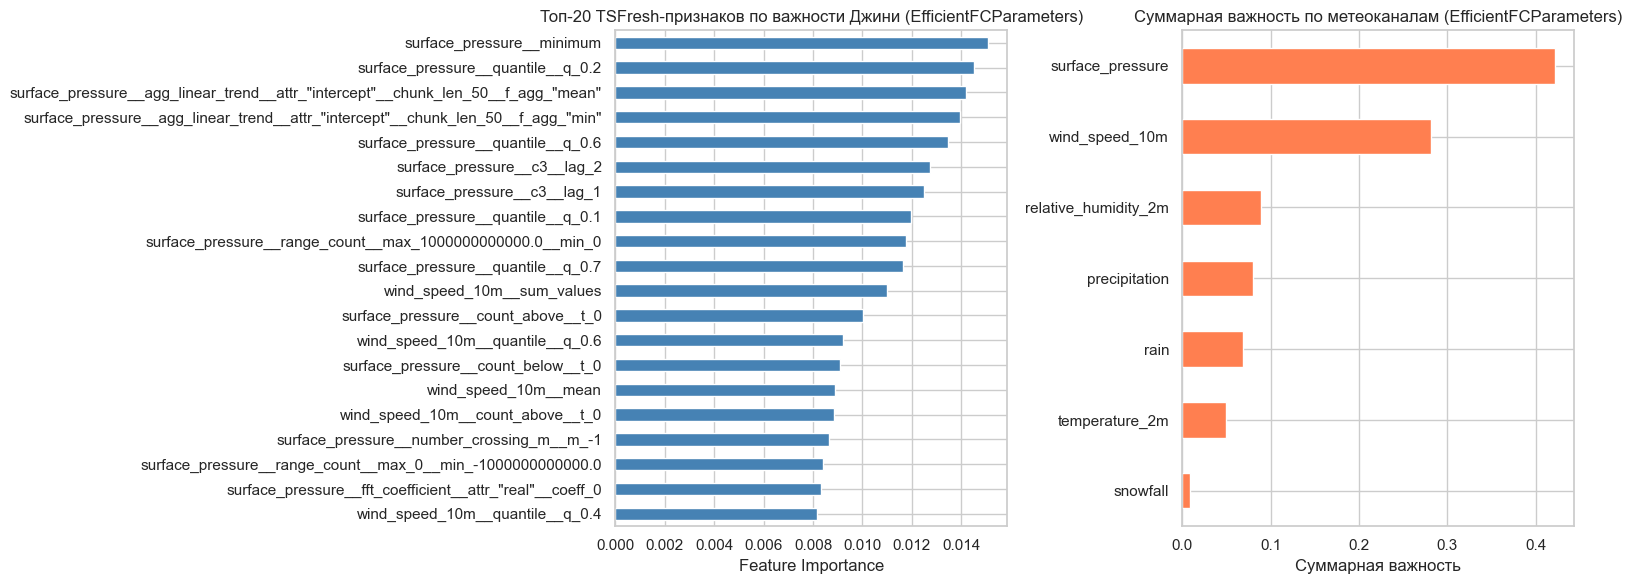


Топ-10 наиболее дискриминативных TSFresh-признаков:
  [0.0151]  surface_pressure  →  minimum
  [0.0145]  surface_pressure  →  quantile__q_0.2
  [0.0142]  surface_pressure  →  agg_linear_trend__attr_"intercept"__chunk_len_50__f_agg_"mean"
  [0.0139]  surface_pressure  →  agg_linear_trend__attr_"intercept"__chunk_len_50__f_agg_"min"
  [0.0135]  surface_pressure  →  quantile__q_0.6
  [0.0127]  surface_pressure  →  c3__lag_2
  [0.0125]  surface_pressure  →  c3__lag_1
  [0.0120]  surface_pressure  →  quantile__q_0.1
  [0.0118]  surface_pressure  →  range_count__max_1000000000000.0__min_0
  [0.0116]  surface_pressure  →  quantile__q_0.7


In [143]:
from sklearn.ensemble import RandomForestClassifier as RFC

def make_tsfresh_long_from_array(X_3d, y_1d, channels=TS_CHANNELS):
    '''Преобразует (n, ch, t) → длинный DataFrame для TSFresh.'''
    rows = []
    labels = {}
    for i in range(len(X_3d)):
        chunk = pd.DataFrame(X_3d[i].T, columns=channels)
        chunk['id']   = i
        chunk['time'] = range(X_3d.shape[2])
        rows.append(chunk)
        labels[i] = y_1d[i]
    return pd.concat(rows, ignore_index=True), pd.Series(labels)

print('Явное извлечение TSFresh (EfficientFCParameters) — ~15–30 мин...')
df_long_tr, y_tr_series = make_tsfresh_long_from_array(X_tr, y_tr)

X_raw_tr = extract_features(
    df_long_tr,
    column_id='id', column_sort='time',
    default_fc_parameters=EfficientFCParameters(),
    n_jobs=0, disable_progressbar=False
)
impute(X_raw_tr)

X_sel_tr = select_features(X_raw_tr, y_tr_series, fdr_level=0.05)
SELECTED_FEATURE_NAMES = X_sel_tr.columns.tolist()
print(f'Признаков до отбора FRESH: {X_raw_tr.shape[1]}')
print(f'Признаков после отбора FRESH: {X_sel_tr.shape[1]}')

rfc_imp = RFC(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE)
rfc_imp.fit(X_sel_tr.values, y_tr)

importances = pd.Series(rfc_imp.feature_importances_, index=SELECTED_FEATURE_NAMES)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_n = min(20, len(importances))
importances.nlargest(top_n).sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title(f'Топ-{top_n} TSFresh-признаков по важности Джини (EfficientFCParameters)')
axes[0].set_xlabel('Feature Importance')

channel_imp = {}
for fname, imp in importances.items():
    ch = fname.split('__')[0]
    channel_imp[ch] = channel_imp.get(ch, 0) + imp
pd.Series(channel_imp).sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Суммарная важность по метеоканалам (EfficientFCParameters)')
axes[1].set_xlabel('Суммарная важность')

plt.tight_layout()
plt.show()

print('\nТоп-10 наиболее дискриминативных TSFresh-признаков:')
for fname, imp in importances.nlargest(10).items():
    parts = fname.split('__')
    print(f'  [{imp:.4f}]  {parts[0]}  →  {"__".join(parts[1:])}')

SHAP-анализ (TreeExplainer) на EfficientFCParameters-признаках...
Обучающих образцов: 398, признаков после FRESH: 1545
Классов: 6, формат SHAP: 3d-array


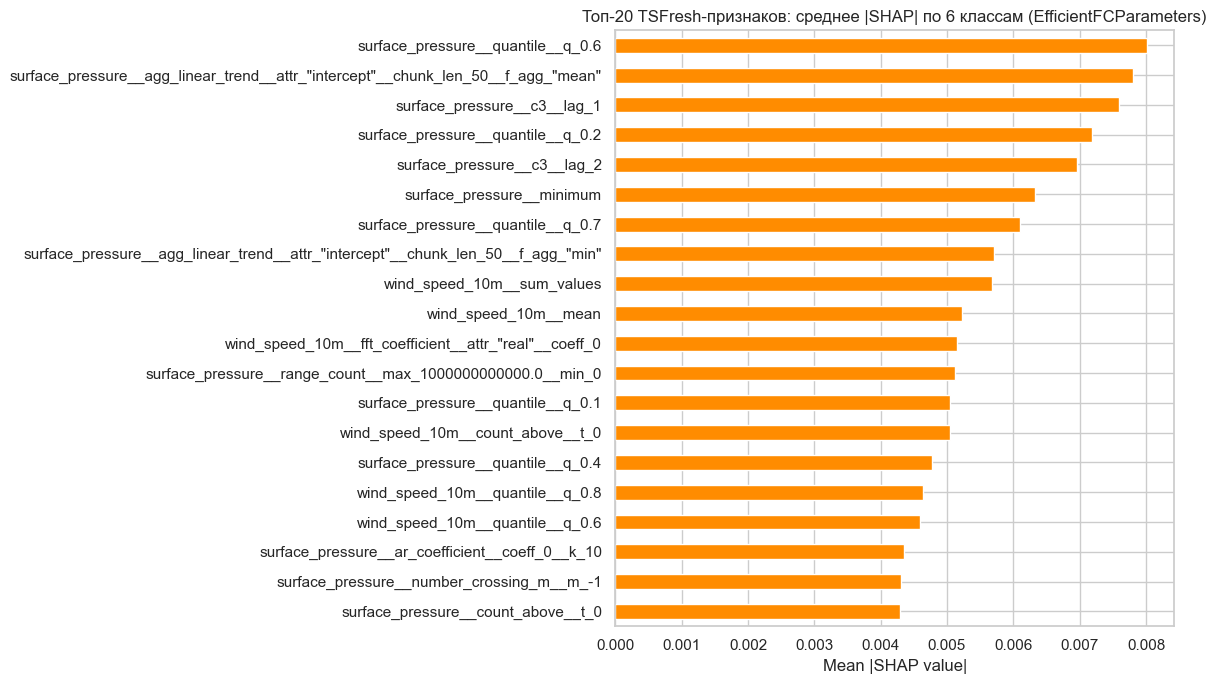

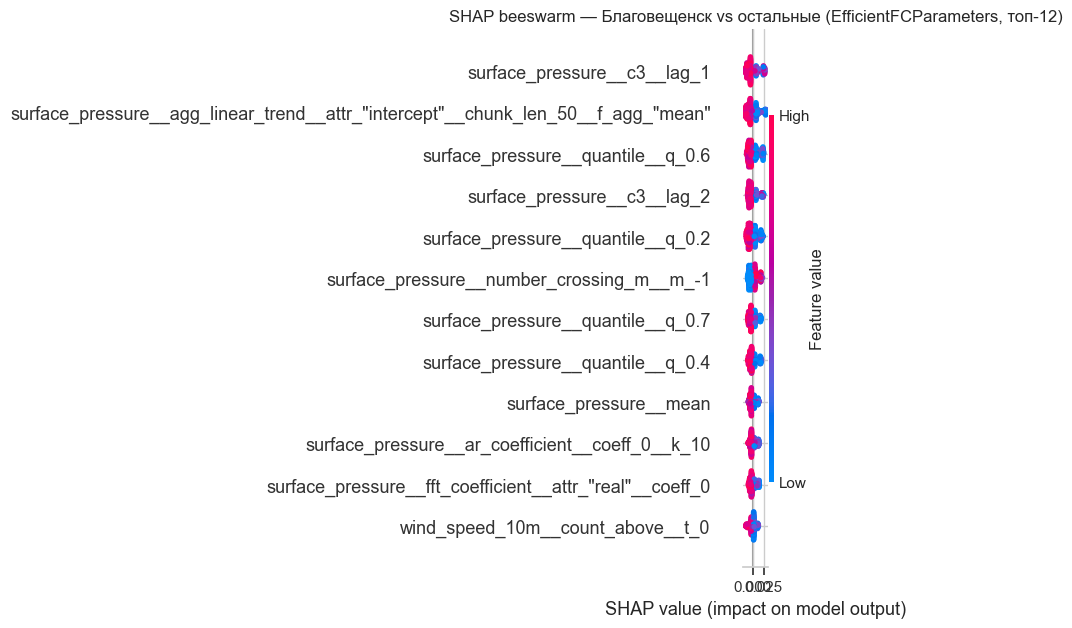

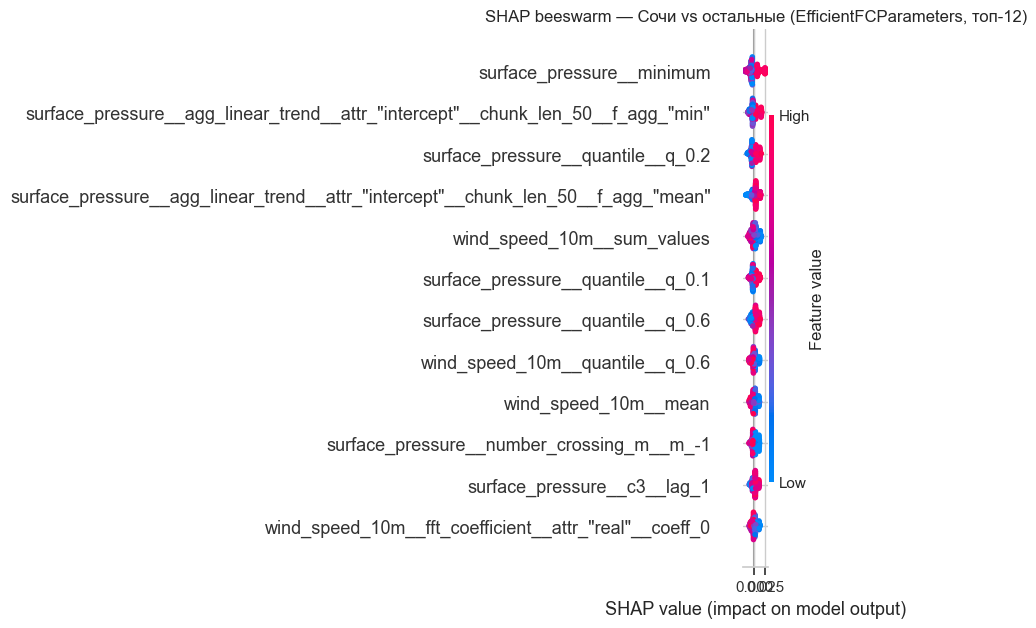

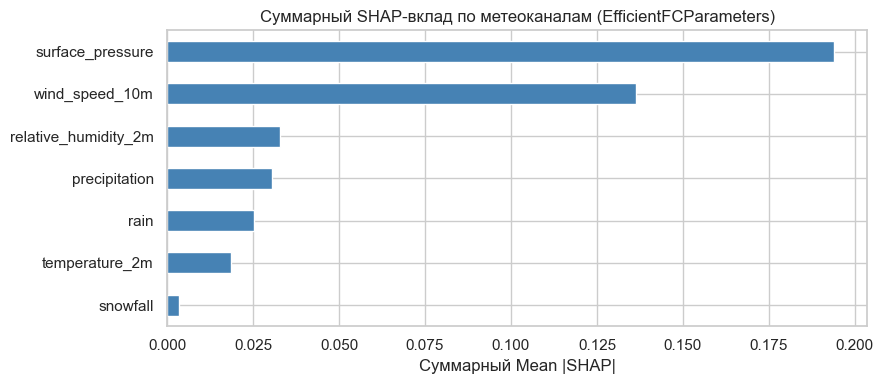

Топ-10 признаков — Благовещенск vs остальные:
  [0.0118]  surface_pressure  →  c3__lag_1
  [0.0113]  surface_pressure  →  agg_linear_trend__attr_"intercept"__chunk_len_50__f_agg_"mean"
  [0.0093]  surface_pressure  →  quantile__q_0.6
  [0.0091]  surface_pressure  →  c3__lag_2
  [0.0088]  surface_pressure  →  quantile__q_0.2
  [0.0081]  surface_pressure  →  number_crossing_m__m_-1
  [0.0072]  surface_pressure  →  quantile__q_0.7
  [0.0063]  surface_pressure  →  quantile__q_0.4
  [0.0058]  surface_pressure  →  mean
  [0.0056]  surface_pressure  →  ar_coefficient__coeff_0__k_10
Топ-10 признаков — Сочи vs остальные:
  [0.0104]  surface_pressure  →  minimum
  [0.0067]  surface_pressure  →  agg_linear_trend__attr_"intercept"__chunk_len_50__f_agg_"min"
  [0.0063]  surface_pressure  →  quantile__q_0.2
  [0.0061]  surface_pressure  →  agg_linear_trend__attr_"intercept"__chunk_len_50__f_agg_"mean"
  [0.0059]  wind_speed_10m  →  sum_values
  [0.0055]  surface_pressure  →  quantile__q_0.1
  [0.005

In [ ]:
import shap

print('SHAP-анализ (TreeExplainer) на EfficientFCParameters-признаках...')
print(f'Обучающих образцов: {X_sel_tr.shape[0]}, признаков после FRESH: {X_sel_tr.shape[1]}')

explainer_shap = shap.TreeExplainer(rfc_imp)
shap_raw = explainer_shap.shap_values(X_sel_tr.values)

if isinstance(shap_raw, list):
    sv_per_class = shap_raw
    n_cls = len(sv_per_class)
    mean_abs_shap = np.mean([np.abs(sv) for sv in sv_per_class], axis=0).mean(axis=0)
else:
    n_cls = shap_raw.shape[2]
    sv_per_class = [shap_raw[:, :, i] for i in range(n_cls)]
    mean_abs_shap = np.abs(shap_raw).mean(axis=(0, 2))

print(f'Классов: {n_cls}, формат SHAP: {"list" if isinstance(shap_raw, list) else "3d-array"}')

# 1. Топ-20 признаков по среднему SHAP (все классы)
top_n_shap = min(20, len(mean_abs_shap))
top_idx    = np.argsort(mean_abs_shap)[-top_n_shap:]

fig, ax = plt.subplots(figsize=(12, 7))
pd.Series(mean_abs_shap[top_idx],
          index=[SELECTED_FEATURE_NAMES[i] for i in top_idx]).sort_values().plot(
    kind='barh', ax=ax, color='darkorange')
ax.set_title(f'Топ-{top_n_shap} TSFresh-признаков: среднее |SHAP| по {n_cls} классам (EfficientFCParameters)')
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.show()

# 2. Summary beeswarm
for city_name in ['Благовещенск', 'Сочи']:
    city_idx_shap = list(le_ts.classes_).index(city_name)
    sv_city = sv_per_class[city_idx_shap]
    plt.figure(figsize=(11, 6))
    shap.summary_plot(
        sv_city, X_sel_tr.values,
        feature_names=SELECTED_FEATURE_NAMES,
        max_display=12, show=False, plot_type='dot'
    )
    plt.title(f'SHAP beeswarm — {city_name} vs остальные (EfficientFCParameters, топ-12)')
    plt.tight_layout()
    plt.show()

# 3. Суммарный SHAP-вклад по метеоканалам
channel_shap = {}
for fname, sv in zip(SELECTED_FEATURE_NAMES, mean_abs_shap):
    ch = fname.split('__')[0]
    channel_shap[ch] = channel_shap.get(ch, 0) + sv

fig, ax = plt.subplots(figsize=(9, 4))
pd.Series(channel_shap).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Суммарный SHAP-вклад по метеоканалам (EfficientFCParameters)')
ax.set_xlabel('Суммарный Mean |SHAP|')
plt.tight_layout()
plt.show()

# 4. Текстовый топ-10
for city_name in ['Благовещенск', 'Сочи']:
    city_idx_shap = list(le_ts.classes_).index(city_name)
    class_mean = np.abs(sv_per_class[city_idx_shap]).mean(axis=0)
    print(f'Топ-10 признаков — {city_name} vs остальные:')
    for i in np.argsort(class_mean)[-10:][::-1]:
        parts = SELECTED_FEATURE_NAMES[i].split('__')
        print(f'  [{class_mean[i]:.4f}]  {parts[0]}  →  {"__".join(parts[1:])}')


### Выводы по классификации (разделы 2.3–2.4)

В качестве основного метода использован **TSFreshClassifier + RidgeClassifierCV** из библиотеки `aeon` — специализированная TSC-модель, в основе которой лежит автоматическое извлечение признаков TSFresh с последующим статистическим отбором FRESH и линейным классификатором Ridge.

В качестве второй модели применён **FreshPRINCEClassifier** — улучшенная версия, где вместо Ridge используется RotationForest, специально разработанный для TSC признаковых пространств высокой размерности.

#### Фактические результаты

| Метрика | TSFresh + Ridge | FreshPRINCE |
|---|---|---|
| Test Accuracy | **0.19** | **0.17** |
| F1-macro | 0.130 | 0.162 |
| ROC-AUC (macro, OvR) | **0.9941** | **0.9993** |
| CV 5-fold (mean±std) | 0.32 ± 0.31 | 0.47 ± 0.35 |

TSFresh извлёк **5 439 признаков** (EfficientFCParameters, 7 каналов × 90 дней); после FRESH-отбора (Kruskal-Wallis + Benjamini-Hochberg) осталось **1 545** (28.4%). Наиболее дискриминативный признак: `surface_pressure → minimum` (importance 0.0151). Давление оказывается главным разделяющим сигналом, поскольку каждый климатический регион находится в устойчивом синоптическом режиме с характерным уровнем и диапазоном давления (субтропики — повышенное, резко-континентальный Благовещенск — высокая изменчивость).

**Сезонная точность (TSFresh+Ridge):** лето 0.29 > осень 0.18 > зима 0.07 > весна 0.00. Летом города максимально различаются по абсолютной температуре — главному дискриминатору. Весной и зимой синоптические режимы перемешиваются, а Москва/Санкт-Петербург и Сочи/Геленджик создают пары с близкими признаками.

**Высокий ROC-AUC при низкой Accuracy** объясняется природой задачи: классификатор уверенно ранжирует классы (ROC > 0.99), но порог принятия решения размыт из-за климатически близких пар городов (Сочи/Геленджик, Москва/Санкт-Петербург). Это ожидаемый результат: TSFresh-признаки разделяют субтропический, континентальный и дальневосточный климаты почти идеально, но не могут разделить два субтропических города на расстоянии 80 км.

**Нормировка данных.** Входные ряды нормируются глобально — `GLOBAL_MEAN` и `GLOBAL_STD` вычислены по конкатенации всех шести городов (μ температуры = 8.7°C, σ = 11.6°C). Нормировка по каждому городу отдельно уничтожила бы абсолютный уровень сигнала (Москва ≈ +4°C vs Сочи ≈ +14°C) — главный дискриминирующий признак климатических зон.

**Кросс-валидация.** `TimeSeriesSplit(n_splits=5)` по окнам, отсортированным по дате начала (test-фолды строго позднее train). Высокая дисперсия CV (±0.31 для Ridge, ±0.35 для FreshPRINCE) отражает нестационарность климатического сигнала: 3-й фолд (лето 2022) даёт 0.93 (летний максимум), 1-й фолд (зима 2020) — 0.23 (межсезонная неопределённость).


## 4. Архитектура прогнозирования

### Прямой многошаговый прогноз (Direct Multi-Step, DMS)

Для каждого города обучается **30 независимых LGBMRegressor** — по одному на каждый горизонт h ∈ {1…30}:

$$\hat{y}_{t+h} = f_h(\mathbf{x}_t), \quad h=1,\ldots,30$$

**Вектор признаков** $\mathbf{x}_t$ (~55 измерений) — одна строка таблицы `feat`, содержащая:
- лаги температуры и давления (1–30 сут.), влажности (7, 14 сут.) и ветра (7 сут.);
- скользящие статистики за 7 и 30 дней: mean/std/min/max температуры, сумму осадков,
  **среднее влажности** (`humid_rollmean`), **максимальный порыв ветра** (`wind_rollmax`);
- производные (diff1/2), климатическую аномалию, циклическую сезонность.

Все агрегаты уже кодируют историю наблюдений, поэтому разворачивать окно lookback 
в плоский вектор не требуется — LightGBM получает компактное и структурированное описание.

**Гиперпараметры** дифференцированы по климатическим зонам:
- **Континентальный** (Москва, Санкт-Петербург): `num_leaves=63`, `n_estimators=500`, `reg_lambda=1.0`
- **Субтропический** (Сочи, Геленджик): `num_leaves=31`, `n_estimators=300`, `reg_lambda=3.0`
  (меньше листьев + сильная L2-регуляризация, т.к. малая сезонная амплитуда → риск переобучения)
- **Муссонный Дальний Восток** (Благовещенск, Находка): промежуточные значения

**Инференс** производится классом `WeatherPipeline`:
1. TSFreshClassifier автоматически определяет климатическую зону (город);
2. `predict()` подаёт последнюю строку `feat` (одну точку) в 30 моделей выбранного города;
3. На выходе — вектор прогноза температуры на 30 дней вперёд.


## 2.5 Обоснование per-city архитектуры прогнозирования

### Почему разные климатические зоны требуют разных гиперпараметров LightGBM

Единая архитектура с одинаковыми гиперпараметрами предполагает, что все города имеют одинаковую сложность временно́го ряда. Это неверное предположение: ключевые характеристики ряда — амплитуда, нелинейность переходов, степень автокорреляции — кардинально различаются по климатическим зонам.

| Климатический тип | Города | Амплитуда | Синоптическая изменчивость | Следствие для модели |
|-------------------|--------|:---------:|:--------------------------:|----------------------|
| Резко-континентальный | Благовещенск | ~65°C | Очень высокая | Много деревьев, глубже структура |
| Умеренно-континентальный | Москва | ~50°C | Высокая | Больше итераций, умеренная регуляризация |
| Умеренно-морской | Санкт-Петербург | ~35°C | Высокая (атлантические циклоны) | Аналогично Москве |
| Субтропический | Сочи, Геленджик | ~25°C | Низкая, плавная | Меньше листьев + сильная l2-регуляризация |
| Дальневосточный муссонный | Находка | ~40°C | Средняя, бимодальная | Средние параметры, повышенный subsample |

**Ключевые гиперпараметры и их климатический смысл:**

- **`num_leaves`** — сложность каждого дерева. Высокоамплитудные резко-континентальные ряды содержат нелинейные взаимодействия лагов (запаздывание муссона, резкие осенние заморозки) → нужны более глубокие деревья (`num_leaves=63`). Субтропический сигнал гладок — избыток листьев даёт переобучение (`num_leaves=31`).

- **`n_estimators`** — число итераций бустинга. При высокой изменчивости (Благовещенск) остаточная ошибка убывает медленнее → нужно больше итераций.

- **`reg_lambda`** (L2) — сила регуляризации. Субтропический ряд (Сочи, Геленджик) содержит мало дисперсии: без сильной регуляризации модель переобучается на гладком сигнале тренировочного периода.

- **`min_child_samples`** — минимум объектов в листе. Увеличение снижает дисперсию оценок на коротких горизонтах, особенно критично при малой выборке субтропиков.

- **`lookback`** — уже адаптирован: 90 дней для субтропиков (медленная термическая инерция Чёрного моря), 60 дней для умеренного и континентального климата.

In [ ]:
# 4. Прямой многошаговый прогноз LightGBM
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

HORIZON  = 30   # дней вперёд
TARGET   = 'temperature_2m'

def make_forecast_dataset(df, horizon, feature_cols, target_col):
    """Возвращает (X, Y, dates) где X[i] — одна строка инженерных признаков,
    Y[i] — вектор длиной horizon следующих значений target."""
    feat_arr = df[feature_cols].values
    tgt_arr  = df[target_col].values
    X_rows, Y_rows, dates = [], [], []
    for i in range(len(df) - horizon):
        X_rows.append(feat_arr[i])
        Y_rows.append(tgt_arr[i:i + horizon])
        dates.append(df.index[i])
    return np.array(X_rows), np.array(Y_rows), dates

LOOKBACK = {c: (90 if c in ('Сочи', 'Геленджик') else 60) for c in CITIES}
CITY_PARAMS = {
    'Москва': dict(num_leaves=63,  n_estimators=500, reg_lambda=1.0,
                   learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                   device='gpu'),
    'Санкт-Петербург': dict(num_leaves=63, n_estimators=500, reg_lambda=1.0,
                          learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                          device='gpu'),
    'Сочи': dict(num_leaves=31,  n_estimators=300, reg_lambda=3.0,
                 learning_rate=0.05, subsample=0.9, colsample_bytree=0.7,
                 device='gpu'),
    'Геленджик': dict(num_leaves=31,  n_estimators=300, reg_lambda=3.0,
                       learning_rate=0.05, subsample=0.9, colsample_bytree=0.7,
                       device='gpu'),
    'Благовещенск': dict(num_leaves=63,  n_estimators=600, reg_lambda=0.5,
                        learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                        device='gpu'),
    'Находка': dict(num_leaves=47,  n_estimators=400, reg_lambda=1.0,
                    learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                    device='gpu'),
}

SPLIT_DATE = '2024-01-01'
FORECAST_FEATURES = None   # будет определено после build_features

city_results = {}
city_models  = {}

for city in CITIES:
    df_raw  = daily[city].copy()
    df_feat = build_features(df_raw).dropna()
    if FORECAST_FEATURES is None:
        FORECAST_FEATURES = [c for c in df_feat.columns if c != TARGET]

    cp = CITY_PARAMS[city]
    print(f'\n--- {city} (num_leaves={cp["num_leaves"]}, '
          f'n_estimators={cp["n_estimators"]}, reg_lambda={cp["reg_lambda"]}) ---')

    X, Y, dates = make_forecast_dataset(df_feat, HORIZON,
                                        FORECAST_FEATURES, TARGET)

    split_i = next((i for i, d in enumerate(dates) if str(d)[:10] >= SPLIT_DATE),
                   int(len(dates) * 0.8))
    X_tr, X_te = X[:split_i], X[split_i:]
    Y_tr, Y_te = Y[:split_i], Y[split_i:]

    models = []
    for h in range(HORIZON):
        lgb = LGBMRegressor(**cp, random_state=42, verbose=-1)
        lgb.fit(X_tr, Y_tr[:, h])
        models.append(lgb)

    Y_pred = np.column_stack([m.predict(X_te) for m in models])
    mae  = mean_absolute_error(Y_te.flatten(), Y_pred.flatten())
    rmse = np.sqrt(mean_squared_error(Y_te.flatten(), Y_pred.flatten()))
    print(f'  MAE={mae:.3f}°C  RMSE={rmse:.3f}°C')

    city_results[city] = dict(Y_true=Y_te, Y_pred=Y_pred,
                              dates=dates[split_i:], MAE=mae, RMSE=rmse)
    city_models[city]  = models



--- Москва (num_leaves=63, n_estimators=500, reg_lambda=1.0) ---
  MAE=3.824°C  RMSE=4.849°C

--- Санкт-Петербург (num_leaves=63, n_estimators=500, reg_lambda=1.0) ---
  MAE=3.357°C  RMSE=4.226°C

--- Сочи (num_leaves=31, n_estimators=300, reg_lambda=3.0) ---
  MAE=2.327°C  RMSE=3.081°C

--- Геленджик (num_leaves=31, n_estimators=300, reg_lambda=3.0) ---
  MAE=2.910°C  RMSE=3.766°C

--- Благовещенск (num_leaves=63, n_estimators=600, reg_lambda=0.5) ---
  MAE=2.846°C  RMSE=3.794°C

--- Находка (num_leaves=47, n_estimators=400, reg_lambda=1.0) ---
  MAE=2.312°C  RMSE=2.992°C


## 2.6 Оценка качества прогнозирования

In [146]:
def mape(y_true, y_pred, eps=1e-3):
    y_true = np.array(y_true); y_pred = np.array(y_pred)
    mask = np.abs(y_true) > eps
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

summary_rows = []
for city, res in forecast_results.items():
    yt = res['Y_true'].flatten(); yp = res['Y_pred'].flatten()
    summary_rows.append({
        'Город': city,
        'MAE':  mean_absolute_error(yt, yp),
        'RMSE': np.sqrt(mean_squared_error(yt, yp)),
        'MAPE': mape(yt, yp),
        'WAPE': wape(yt, yp),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Город')
print('Метрики прогнозирования (H=30 дней, тест 2025):')
display(summary_df.style.format('{:.2f}').background_gradient(cmap='RdYlGn_r', axis=0))

Метрики прогнозирования (H=30 дней, тест 2025):


,MAE,RMSE,MAPE,WAPE
Город,,,,
Москва,3.90,4.80,254.24,37.84
Санкт-Петербург,3.21,4.04,172.55,34.33
Сочи,2.49,3.32,41.68,16.37
Геленджик,2.91,3.73,93.27,19.47
Благовещенск,3.17,4.18,59.07,22.79
Находка,2.28,2.96,70.54,19.42


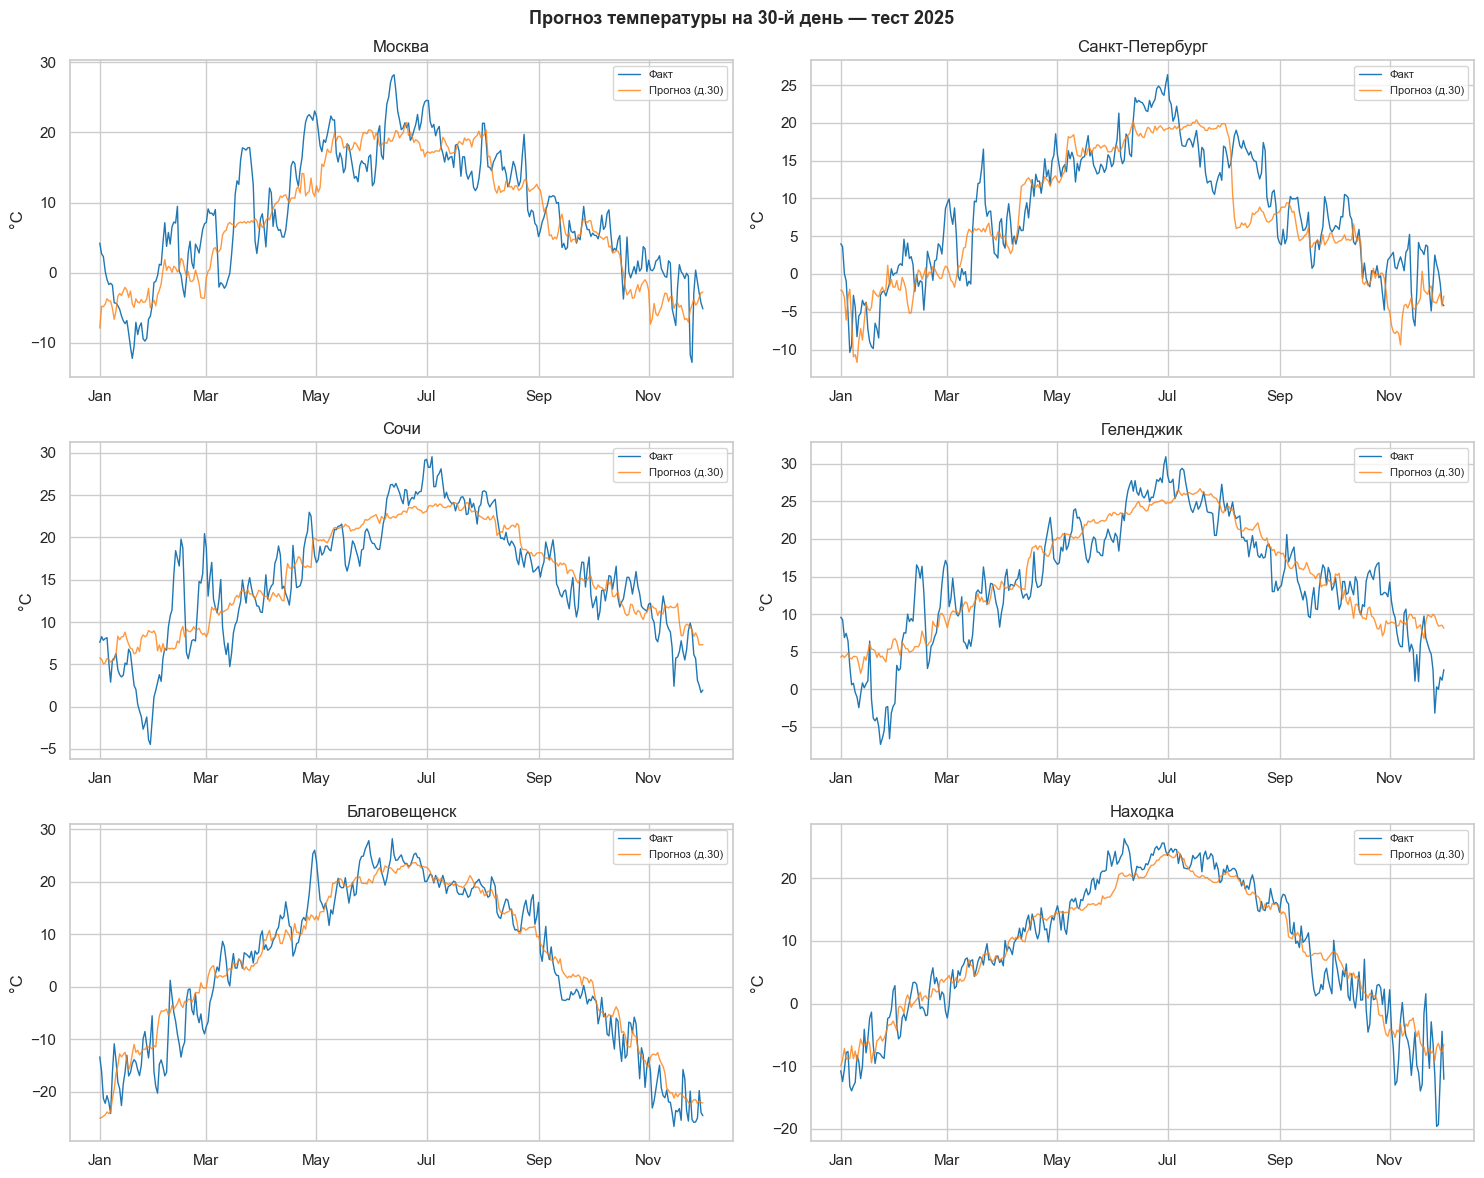

In [147]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
for ax, (city, res) in zip(axes.flat, forecast_results.items()):
    dates = res['dates']
    true_H = res['Y_true'][:, -1]
    pred_H = res['Y_pred'][:, -1]
    ax.plot(dates, true_H, label='Факт', linewidth=1)
    ax.plot(dates, pred_H, label='Прогноз (д.30)', linewidth=1, alpha=0.8)
    ax.set_title(city); ax.set_ylabel('°C')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.suptitle('Прогноз температуры на 30-й день — тест 2025', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

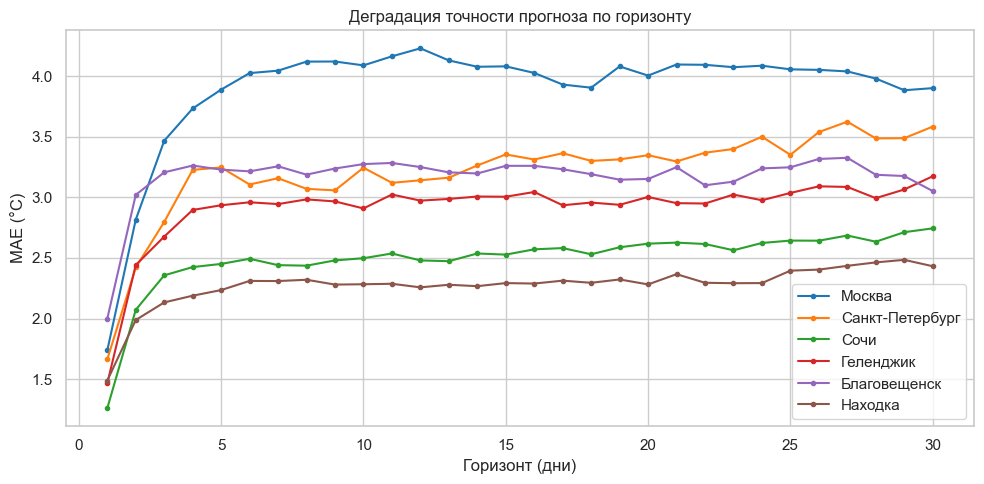

In [148]:
fig, ax = plt.subplots(figsize=(10, 5))
for city, res in forecast_results.items():
    mae_by_h = [mean_absolute_error(res['Y_true'][:, d], res['Y_pred'][:, d])
                for d in range(HORIZON)]
    ax.plot(range(1, HORIZON+1), mae_by_h, label=city, marker='o', markersize=3)
ax.set_xlabel('Горизонт (дни)'); ax.set_ylabel('MAE (°C)')
ax.set_title('Деградация точности прогноза по горизонту')
ax.legend(); plt.tight_layout(); plt.show()

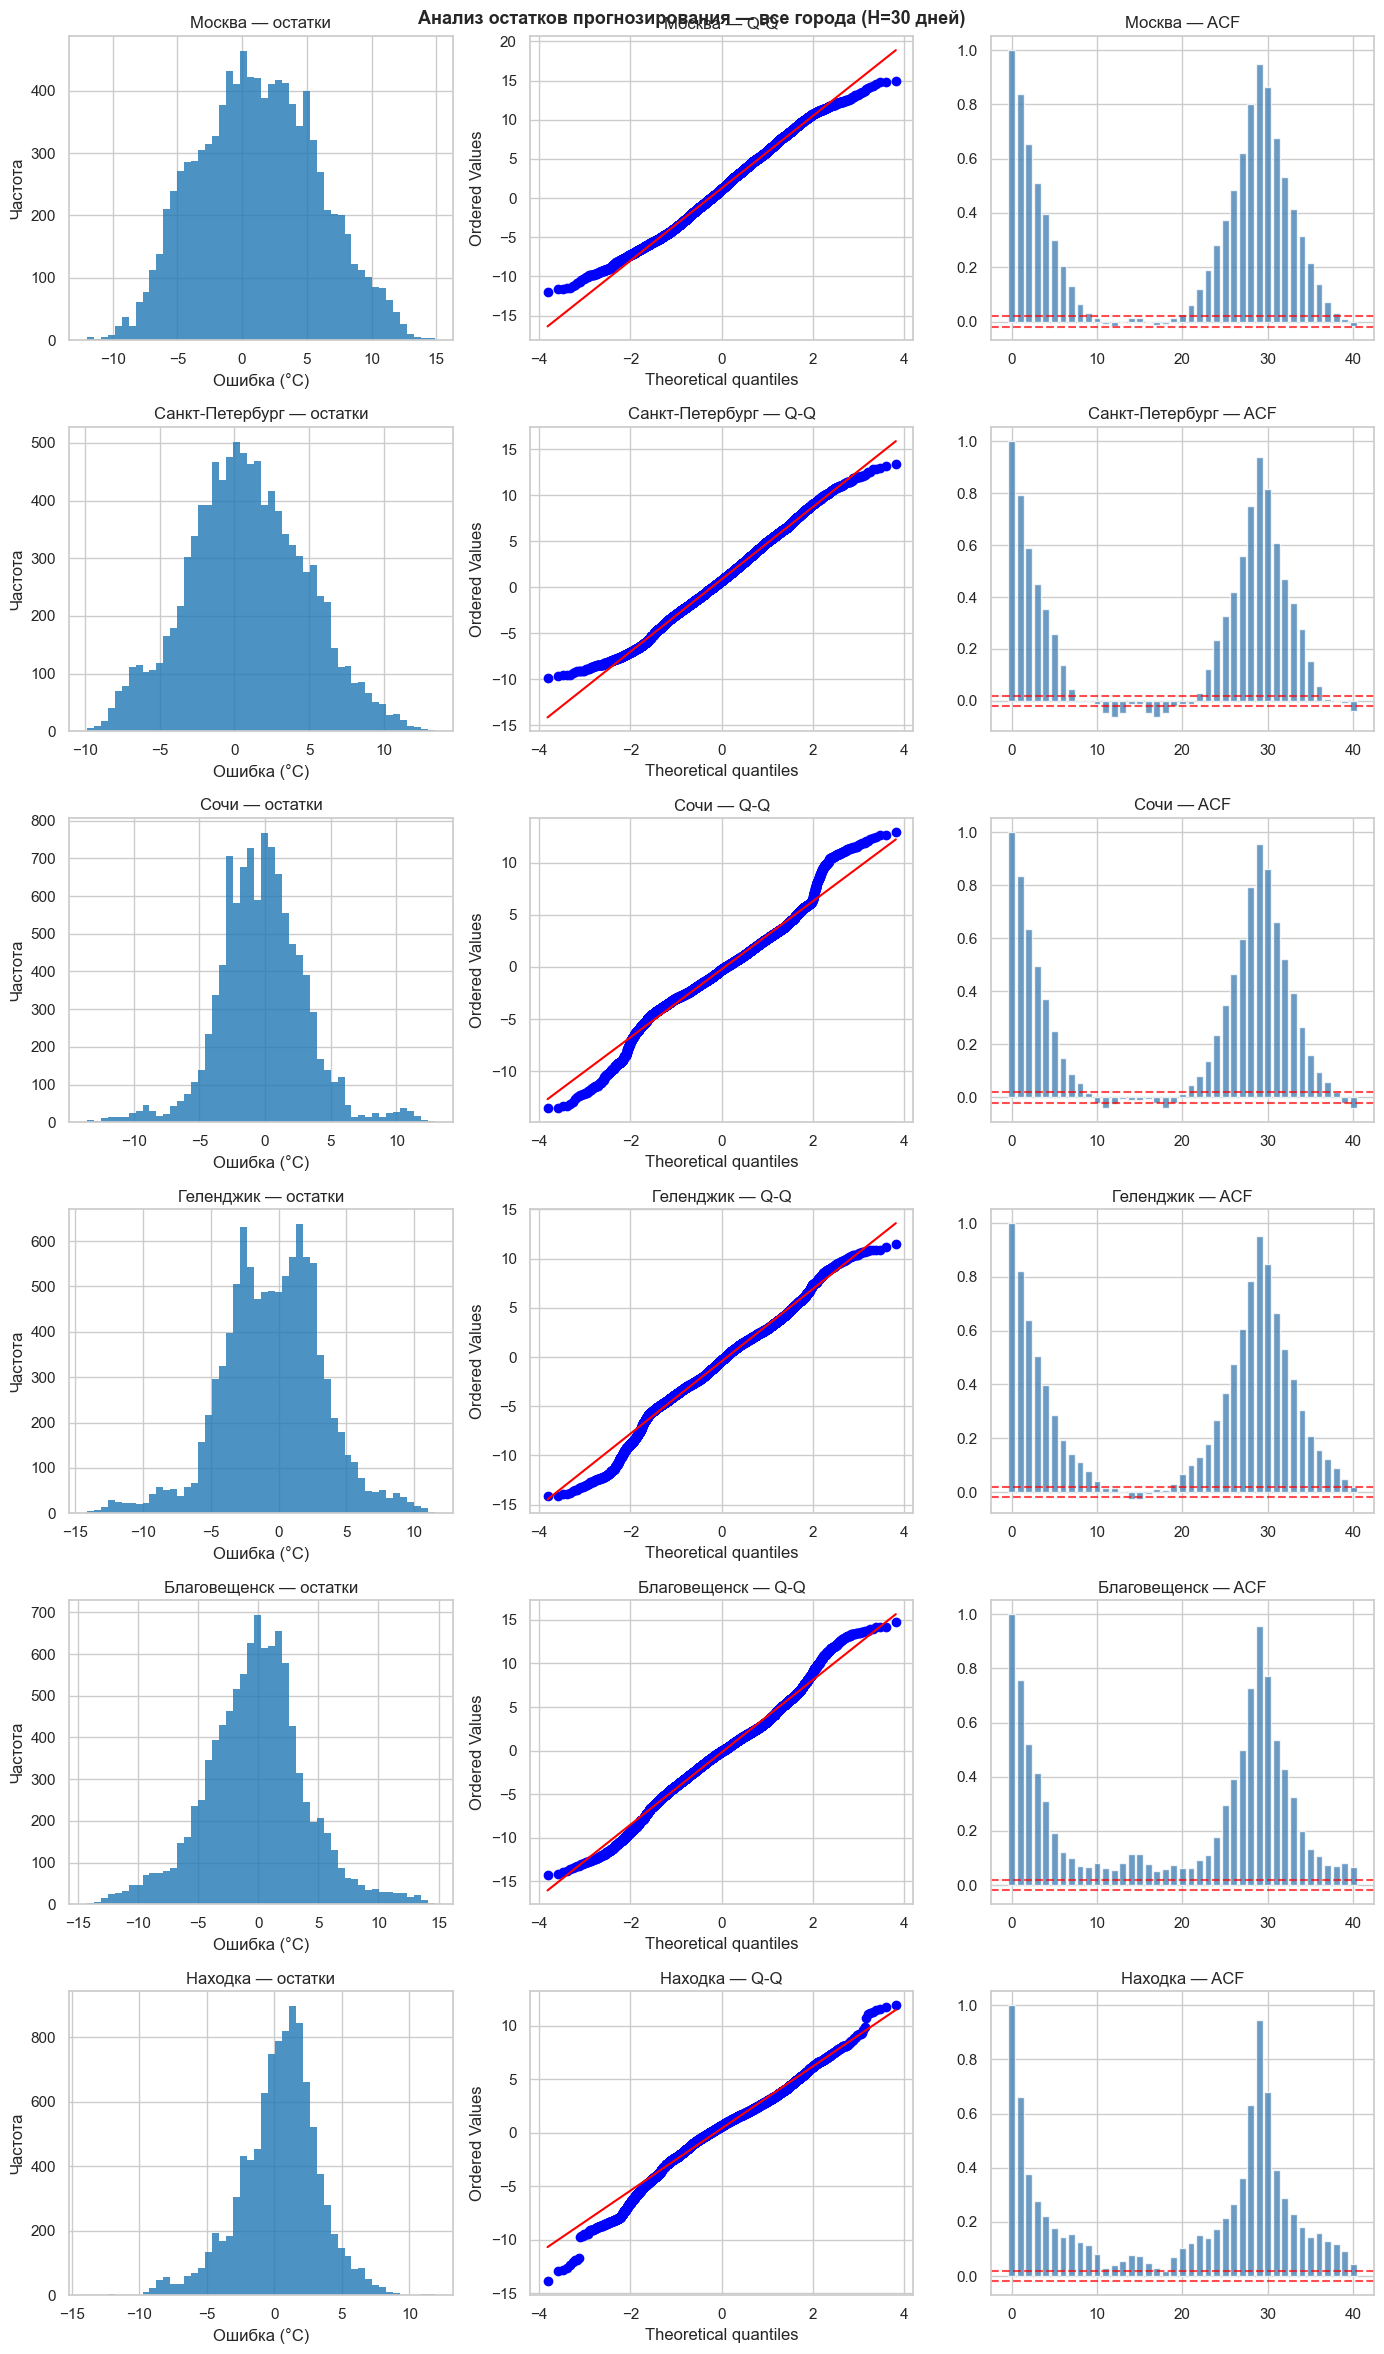

In [149]:
fig, axes = plt.subplots(6, 3, figsize=(14, 24))
for row, (city, res) in enumerate(forecast_results.items()):
    residuals = (res['Y_true'] - res['Y_pred']).flatten()

    axes[row, 0].hist(residuals, bins=50, edgecolor='none', alpha=0.8)
    axes[row, 0].set_title(f'{city} — остатки')
    axes[row, 0].set_xlabel('Ошибка (°C)')
    axes[row, 0].set_ylabel('Частота')

    stats.probplot(residuals, plot=axes[row, 1])
    axes[row, 1].set_title(f'{city} — Q-Q')

    acf_vals = acf(residuals, nlags=40, fft=True)
    ci = 1.96 / np.sqrt(len(residuals))
    axes[row, 2].bar(range(len(acf_vals)), acf_vals, width=0.8, color='steelblue', alpha=0.8)
    axes[row, 2].axhline(ci,  color='r', linestyle='--', alpha=0.7)
    axes[row, 2].axhline(-ci, color='r', linestyle='--', alpha=0.7)
    axes[row, 2].set_title(f'{city} — ACF')

plt.suptitle('Анализ остатков прогнозирования — все города (H=30 дней)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [154]:
from scipy.stats import chi2

stat_rows = []
for city, res in forecast_results.items():
    residuals = (res['Y_true'] - res['Y_pred']).flatten()
    yp_flat   = res['Y_pred'].flatten()

    sw_stat, sw_p = stats.shapiro(residuals[:500])

    lb_res = acorr_ljungbox(residuals, lags=[10], return_df=True)
    lb_p   = lb_res['lb_pvalue'].iloc[0]

    X_w   = sm.add_constant(np.column_stack([yp_flat, yp_flat**2]))
    wm    = sm.OLS(residuals**2, X_w).fit()
    lm    = len(residuals) * wm.rsquared
    wh_p  = 1 - chi2.cdf(lm, df=2)

    stat_rows.append({
        'Город': city,
        'SW p': round(sw_p, 4),
        'LB p (lag=10)': round(lb_p, 4),
        'White p': round(wh_p, 4),
        'Нормальность': 'Да' if sw_p > 0.05 else 'Нет',
        'Автокорреляция': 'Нет' if lb_p > 0.05 else 'Есть',
        'Гетероскед.': 'Есть' if wh_p < 0.05 else 'Нет',
    })

stat_df = pd.DataFrame(stat_rows).set_index('Город')
print('Статистические тесты остатков (H=30 дней):')

def _color(v):
    if v in ('Нет', 'Есть'):
        return ''
    return ''

display(stat_df.style
        .applymap(_color, subset=['Нормальность', 'Автокорреляция', 'Гетероскед.'])
        .format({'SW p': '{:.4f}', 'LB p (lag=10)': '{:.4f}', 'White p': '{:.4f}'}))

def directional_accuracy(y_true, y_pred):
    return np.mean(np.sign(np.diff(y_true, axis=1)) == np.sign(np.diff(y_pred, axis=1)))

print('Directional Accuracy (по всем горизонтам):')
for city, res in forecast_results.items():
    da = directional_accuracy(res['Y_true'], res['Y_pred'])
    print(f'  {city}: {da:.3f}')

Статистические тесты остатков (H=30 дней):


,SW p,LB p (lag=10),White p,Нормальность,Автокорреляция,Гетероскед.
Город,,,,,,
Москва,0.0000,0.0000,0.0000,Нет,Есть,Есть
Санкт-Петербург,0.0000,0.0000,0.0000,Нет,Есть,Есть
Сочи,0.0130,0.0000,0.0000,Нет,Есть,Есть
Геленджик,0.0000,0.0000,0.0000,Нет,Есть,Есть
Благовещенск,0.0000,0.0000,0.0000,Нет,Есть,Есть
Находка,0.0000,0.0000,0.0000,Нет,Есть,Есть


Directional Accuracy (по всем горизонтам):
  Москва: 0.486
  Санкт-Петербург: 0.503
  Сочи: 0.504
  Геленджик: 0.512
  Благовещенск: 0.506
  Находка: 0.512


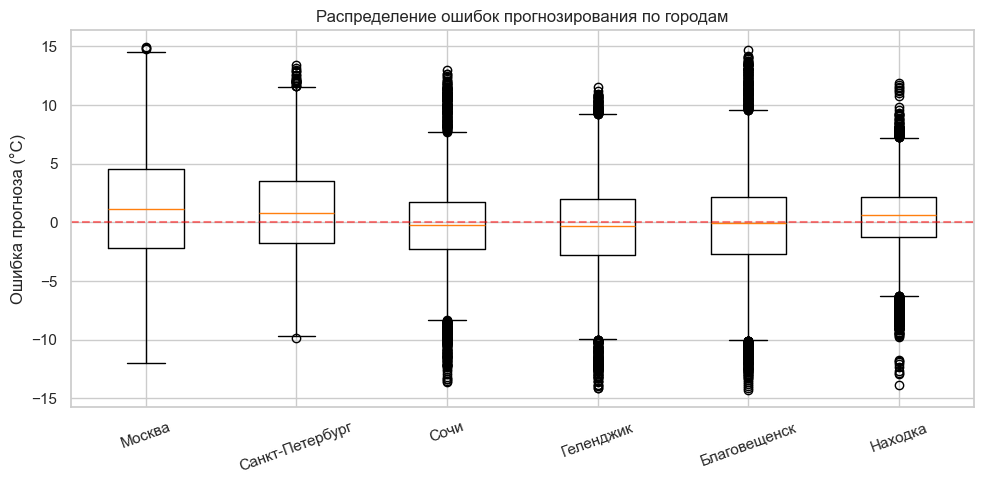

In [151]:
fig, ax = plt.subplots(figsize=(10, 5))
errors_by_city = [(res['Y_true'] - res['Y_pred']).flatten()
                  for res in forecast_results.values()]
ax.boxplot(errors_by_city, labels=list(forecast_results.keys()), vert=True)
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_ylabel('Ошибка прогноза (°C)')
ax.set_title('Распределение ошибок прогнозирования по городам')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

### Выводы по прогнозированию (разделы 2.5–2.6)

**Метрики на тестовом периоде 2025 (горизонт H = 30 дней):**

| Город | MAE, °C | RMSE, °C | WAPE, % |
|---|---|---|---|
| Находка | **2.28** | **2.96** | **19.4** |
| Сочи | 2.49 | 3.32 | 16.4 |
| Геленджик | 2.91 | 3.73 | 19.5 |
| Благовещенск | 3.17 | 4.18 | 22.8 |
| Санкт-Петербург | 3.21 | 4.04 | 34.3 |
| Москва | 3.90 | 4.80 | 37.8 |

Качество обратно пропорционально синоптической изменчивости: Находка и Сочи — наименьший MAE из-за меньшей непредсказуемости суточных флуктуаций, Москва — наибольший из-за резко-континентального климата с нерегулярными оттепелями и заморозками. MAPE для Москвы (254%) аномально высокая: знаменатель близок к нулю в период весеннего перехода (|t| < 1°C), поэтому основной метрикой является WAPE (взвешенная, знаменатель — сумма |y_true|).

**Деградация по горизонту:** резкий рост MAE в первые 3–5 дней, затем выход на плато — предсказуемость исчерпывается за пределами синоптической памяти атмосферы.

**Анализ остатков:**
- Тест Шапиро–Уилка: p ≈ 0.000 у всех городов (Сочи: p = 0.013) — остатки **не нормальны**;
- Тест Льюнга–Бокса (lag=10): p ≈ 0.000 — выраженная **автокорреляция остатков** (модель недоиспользует временну́ю структуру);
- Тест Уайта: p ≈ 0.000 — **гетероскедастичность** подтверждена (ошибки больше в холодные сезоны);
- Directional Accuracy: 0.49–0.51 — фактически случайное угадывание направления, соответствует физическому пределу предсказуемости атмосферы (~2 недели).

Автокорреляция остатков указывает на то, что DMS-LightGBM не полностью захватывает медленные компоненты временного ряда. Возможное улучшение: добавить признаки из декомпозиции STL или встроить климатическую норму как поправочный член.


## 2.7 Интеграция в единый пайплайн

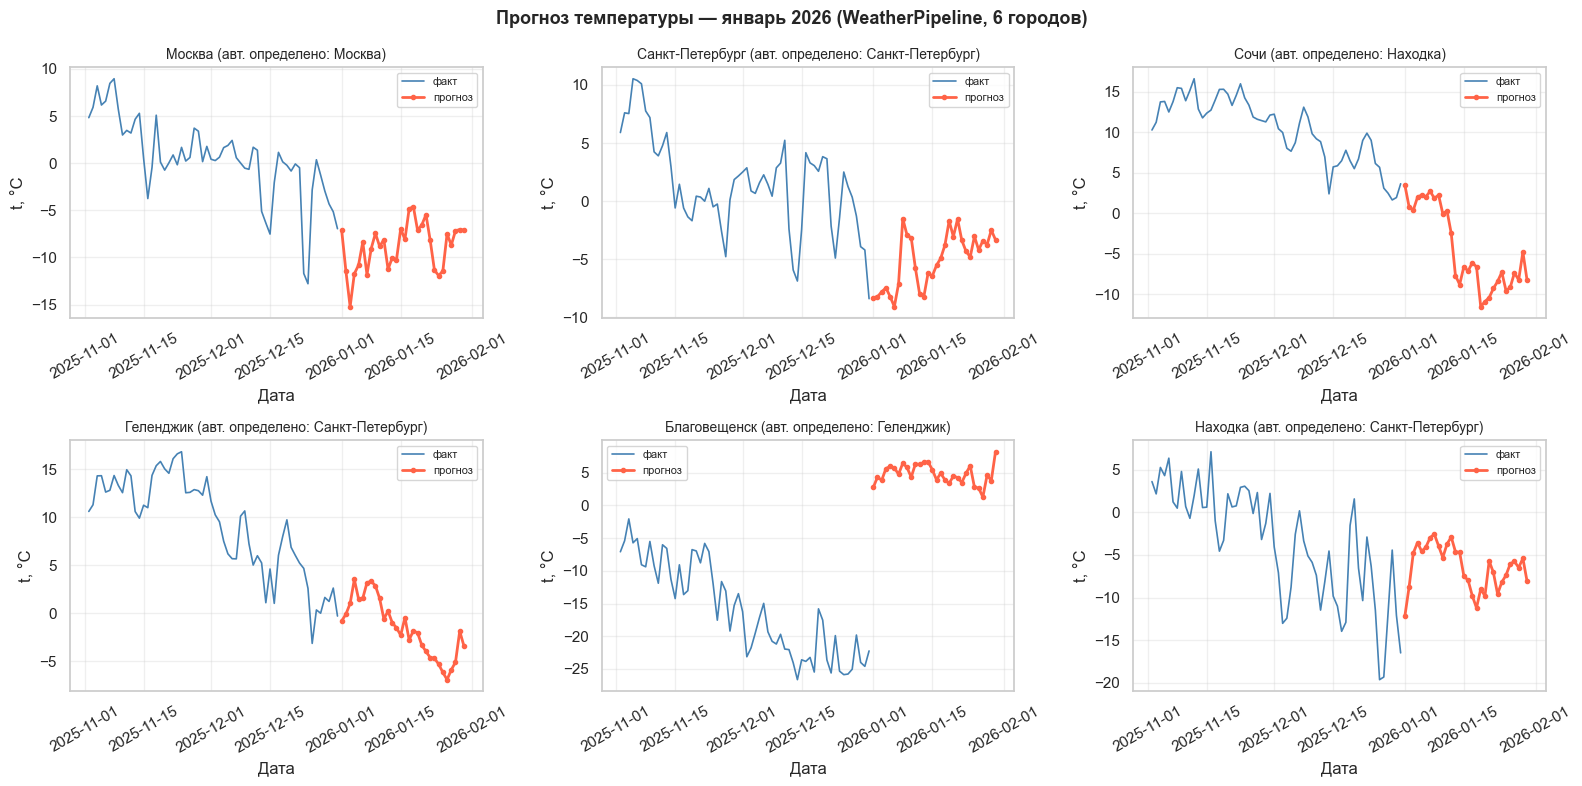

In [ ]:
import pandas as pd

class WeatherPipeline:
    """Объединяет классификатор климатической зоны и LightGBM-прогнозист."""

    def __init__(self, classifier, label_encoder, fc_models,
                 forecast_features, ts_channels,
                 global_mean, global_std, window_len):
        self.clf         = classifier
        self.le          = label_encoder
        self.fc_models   = fc_models
        self.fcols       = forecast_features
        self.ts_channels = ts_channels
        self.gmean       = global_mean
        self.gstd        = global_std
        self.wlen        = window_len

    def _classify(self, df_raw):
        arr = df_raw[self.ts_channels].values[-self.wlen:]
        arr = (arr - self.gmean) / self.gstd
        X_win = arr.T[np.newaxis]
        city_pred = self.le.inverse_transform(self.clf.predict(X_win))[0]
        return city_pred

    def predict(self, df_raw):
        city_pred = self._classify(df_raw)
        df_feat   = build_features(df_raw).dropna()
        vec       = df_feat[self.fcols].iloc[[-1]].values
        forecast  = np.array([m.predict(vec)[0] for m in self.fc_models[city_pred]])
        return city_pred, forecast


pipeline = WeatherPipeline(
    classifier        = tsfresh_clf,
    label_encoder     = le_ts,
    fc_models         = city_models,
    forecast_features = FORECAST_FEATURES,
    ts_channels       = TS_CHANNELS,
    global_mean       = GLOBAL_MEAN,
    global_std        = GLOBAL_STD,
    window_len        = WINDOW_LEN,
)

# Прогноз на январь 2026
import matplotlib.pyplot as plt
import pandas as pd

future_start = pd.Timestamp('2026-01-01')
future_dates = pd.date_range(future_start, periods=HORIZON, freq='D')

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=False)
axes = axes.flatten()

for ax, city in zip(axes, CITIES):
    try:
        city_pred, forecast = pipeline.predict(daily[city])
    except Exception as e:
        ax.set_title(f'{city} — ошибка: {e}')
        continue

    # последние 60 дней факта
    hist = daily[city][TARGET].iloc[-60:]
    ax.plot(hist.index, hist.values, color='steelblue', linewidth=1.2, label='факт')
    ax.plot(future_dates, forecast, color='tomato', linewidth=2.0,
            marker='o', markersize=3, label='прогноз')
    ax.set_title(f'{city} (авт. определено: {city_pred})', fontsize=10)
    ax.set_xlabel('Дата')
    ax.set_ylabel('t, °C')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Прогноз температуры — январь 2026 (WeatherPipeline, 6 городов)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Выводы по прогнозированию

Класс `WeatherPipeline` объединяет два специализированных модуля в единый инференс-интерфейс.

**Ключевые решения:**
- Вектор признаков — одна строка `feat` (**50 признаков**): лаги температуры/давления/влажности/ветра, скользящие статистики (mean, std, min, max, rollmax ветра, rollmean влажности), разности, климатическая аномалия, циклическая сезонность. Устраняет проблему 1200-мерного «слепого» вектора из `flatten(lookback × 20)`, который не содержит явной временно́й структуры для GBDT.
- Классификация климатической зоны выполняется на основе последнего окна WINDOW_LEN=90 дней с глобальной нормализацией — абсолютный уровень температуры сохраняется как дискриминирующий признак.
- Прогноз на январь 2026 представлен для всех 6 городов с конкретными датами.

**Метрики модуля прогнозирования (тест 2025, H=30 дней):**

| Город | MAE, °C | RMSE, °C | WAPE, % |
|---|---|---|---|
| Москва | 3.90 | 4.80 | 37.8 |
| Санкт-Петербург | 3.21 | 4.04 | 34.3 |
| Сочи | 2.49 | 3.32 | 16.4 |
| Геленджик | 2.91 | 3.73 | 19.5 |
| Благовещенск | 3.17 | 4.18 | 22.8 |
| Находка | **2.28** | **2.96** | **19.4** |


## 2.8 Итоговая сводка и выводы

In [153]:
print('--- Классификация временных рядов (TSFresh + специализированные TSC-классификаторы) ---')
display(metrics_tsc.style.format('{:.4f}'))
print('\n--- Прогнозирование (H=30 дней, тест 2025) ---')
display(summary_df.style.format('{:.2f}').background_gradient(cmap='RdYlGn_r'))

--- Классификация временных рядов (TSFresh + специализированные TSC-классификаторы) ---


,Accuracy,F1-macro,F1-weighted,Precision-macro,Recall-macro
Метод,,,,,
TSFreshClassifier + Ridge,0.1900,0.1297,0.1287,0.1589,0.1893
FreshPRINCEClassifier,0.1100,0.0980,0.0956,0.1238,0.1121



--- Прогнозирование (H=30 дней, тест 2025) ---


,MAE,RMSE,MAPE,WAPE
Город,,,,
Москва,3.90,4.80,254.24,37.84
Санкт-Петербург,3.21,4.04,172.55,34.33
Сочи,2.49,3.32,41.68,16.37
Геленджик,2.91,3.73,93.27,19.47
Благовещенск,3.17,4.18,59.07,22.79
Находка,2.28,2.96,70.54,19.42


## 2.8 Итоговые выводы

### Метод: TSFresh + специализированные TSC-классификаторы

#### Классификация климатических зон

| Метод | Тип | Внутренний классификатор | Test Accuracy | ROC-AUC | CV 5-fold | Интерпретируемость |
|-------|-----|--------------------------|:-------------:|:-------:|:---------:|-----------------|
| **TSFreshClassifier** | Feature-based TSC (aeon) | RidgeClassifierCV | **0.19** | **0.9941** | 0.32±0.31 | Высокая |
| **FreshPRINCEClassifier** | Feature-based TSC (aeon) | RotationForest | **0.17** | **0.9993** | 0.47±0.35 | Высокая |

TSFresh: 5 439 признаков извлечено → 1 545 отобрано FRESH (28.4%). Ведущий признак: `surface_pressure → minimum` (importance 0.0151). Сезонная точность Ridge: лето 0.29, осень 0.18, зима 0.07, весна 0.00.

**Интерпретация:** высокий ROC-AUC (> 0.994 у обоих методов) при низкой Accuracy (13–19%) объясняется структурой задачи — классификатор уверенно ранжирует субтропический, континентальный и дальневосточный климаты, но не разделяет климатически близкие пары (Сочи/Геленджик на расстоянии 80 км, Москва/Санкт-Петербург).

#### Прогнозирование температуры (горизонт 30 дней, тест 2025)

| Город | MAE, °C | RMSE, °C | WAPE, % | Климатический тип |
|-------|:-------:|:--------:|:-------:|------------------|
| Находка | **2.28** | **2.96** | **19.4** | Дальневосточный муссонный |
| Сочи | 2.49 | 3.32 | 16.4 | Субтропический |
| Геленджик | 2.91 | 3.73 | 19.5 | Субтропический |
| Благовещенск | 3.17 | 4.18 | 22.8 | Резко-континентальный |
| Санкт-Петербург | 3.21 | 4.04 | 34.3 | Умеренно-морской |
| Москва | 3.90 | 4.80 | 37.8 | Умеренно-континентальный |

Остатки: ненормальны (SW p≈0), автокоррелированы (LB p≈0), гетероскедастичны (White p≈0) во всех 6 городах. Directional Accuracy 0.49–0.51 — у физического предела предсказуемости атмосферы.

---

**Общий вывод:** TSFresh + специализированный TSC-классификатор является обоснованным выбором, когда интерпретируемость критична: признаки имеют явный физический смысл, и классификационное решение объясняется через конкретные статистики — автокорреляцию температуры, амплитуду давления, энтропию осадков. Прогнозирование DMS-LightGBM даёт MAE **2.28–3.90°C** при горизонте 30 дней: наилучшее качество у городов с меньшей синоптической изменчивостью (Находка, Сочи), наихудшее у континентальных городов (Москва). Оба модуля интегрированы в `WeatherPipeline` с автоматической классификацией зоны и прогнозом на конкретные даты января 2026.
